# Reconstruction de l'environnement à l'aide d'un CNN à partir des signaux reçus

## Données

C'est un fichier .mat avec un champ "data" qui contient une matrice de 41 * 2001 signaux et un champ "map" qui contient l'état réel de la carte

Le code fait un apprentissage basique à développer plus


# 1) Imports

In [1]:
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import random
import copy
import os
from scipy.ndimage import binary_erosion, binary_dilation


In [2]:
mode_entrainement = True 
mode_chargement = False 

# 2) Charger les données

In [3]:
DATA_FILES = [
    ('3Rond',              'NOUVEAU_8capteurs_300samples_3_rond.mat', 1500)
]
SIGNAL_START = DATA_FILES[0][2]   # on ignore la partie aller (émission)
DATA_PATH = DATA_FILES[0][1]
device = torch.device('cpu')
if not os.path.exists(DATA_PATH):
    print(f"Erreur : fichier '{DATA_PATH}' introuvable.")
else:
    raw_data = loadmat(DATA_PATH)["results"].squeeze()

    list_experiments = []
    for exp in raw_data:
        # Ignorer les entrées vides (première ligne du struct MATLAB)
        if np.array(exp['data']).size > 0:
            list_experiments.append(exp)

    print(f"Échantillons valides : {len(list_experiments)}")

Échantillons valides : 300


# 3) Séparer les inputs et les outputs

On garde seulement à partir de la 1200 ème colonne les signaux pour limiter la taille et ne pas compter le trajet aller.

Pour la matrice de sortie comme c'est majoritairement des 0 on ne garde que l'espace où se trouve la demi sphère.

In [4]:
list_signals = []
list_outputs = []

for exp in list_experiments:
    signals         = np.array(exp['data']).squeeze()   # (9, 2001)
    visible_section = np.array(exp['visible_section']).squeeze()   # (150, 150)

    list_signals.append(signals[:, SIGNAL_START:])   # (9, 801)
    list_outputs.append(visible_section)             # (150, 150) — cible : zone visible

X = np.array(list_signals, dtype=np.float32)   # (N, 9, 801)
X_raw = np.array(list_signals, dtype=np.float32)
y = np.array(list_outputs, dtype=np.float32)   # (N, 150, 150)

print(f"Shape X (signaux) : {X.shape}")
print(f"Shape y (visible) : {y.shape}")
ratio_pos = y.mean()
print(f"Ratio pixels positifs (visible_section) : {ratio_pos*100:.2f}%")


Shape X (signaux) : (300, 8, 2056)
Shape y (visible) : (300, 150, 150)
Ratio pixels positifs (visible_section) : 0.11%


# 4) Normalisation

Il est necessaire de normaliser les données pour l'apprentissage

In [5]:
# Normalisation par capteur : moyenne/std calculées sur l'axe temps+samples
# Shape X : (N, 9, 801) → mean/std sur axes (0, 2) → (1, 9, 1)
mean_per_ch = X.mean(axis=(0, 2), keepdims=True)
std_per_ch  = X.std(axis=(0, 2),  keepdims=True)
std_per_ch[std_per_ch == 0] = 1.0

X_normalized = (X - mean_per_ch) / std_per_ch
print(f"Après normalisation — mean: {X_normalized.mean():.4f}, std: {X_normalized.std():.4f}")


Après normalisation — mean: 0.0000, std: 1.0000


# 5) Visualisation des données

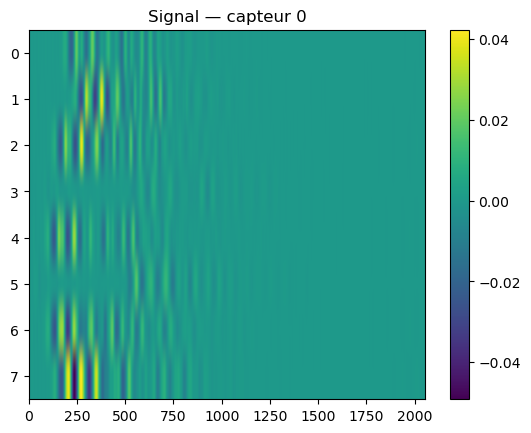

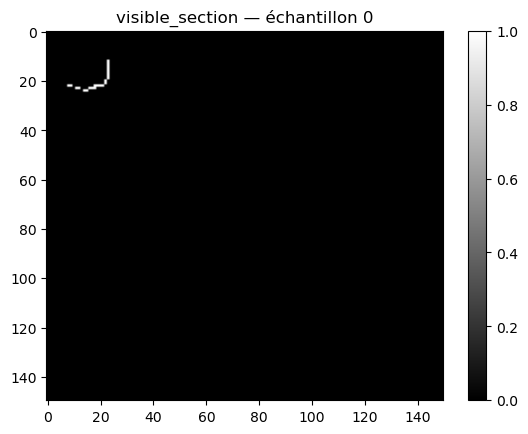

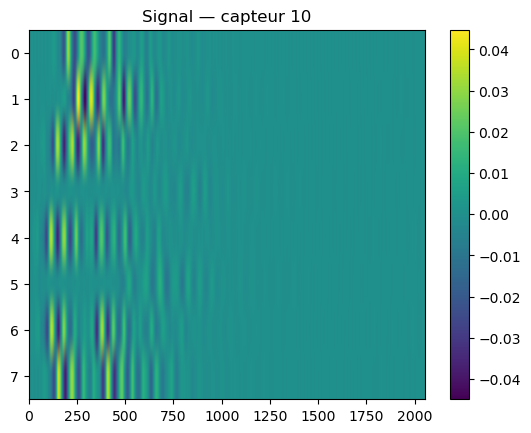

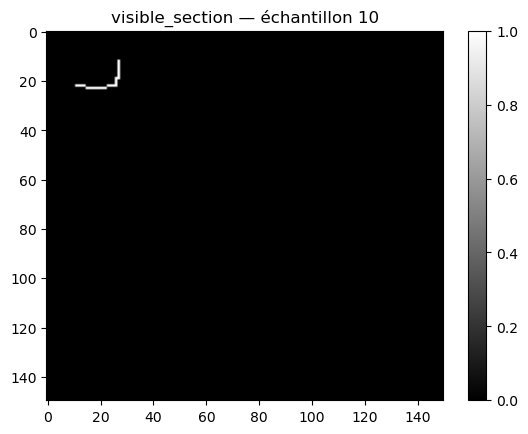

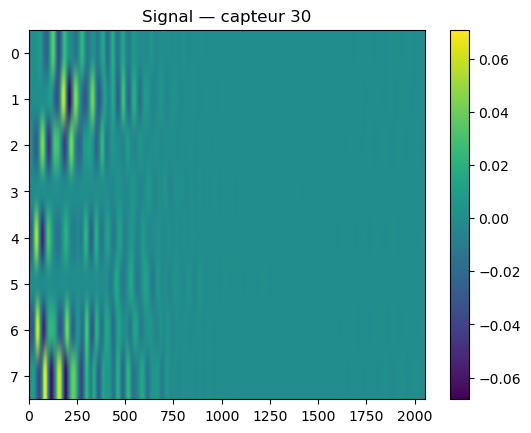

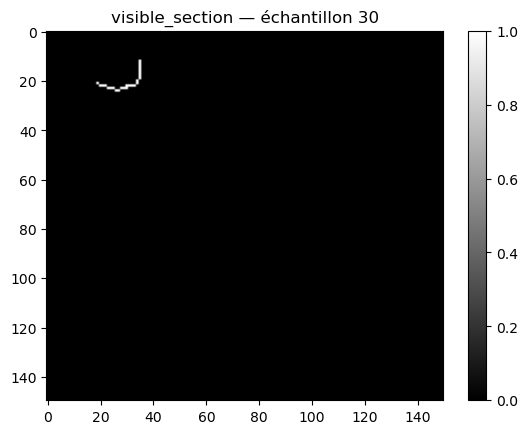

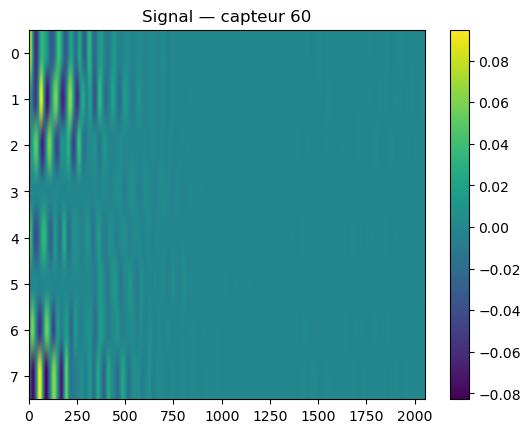

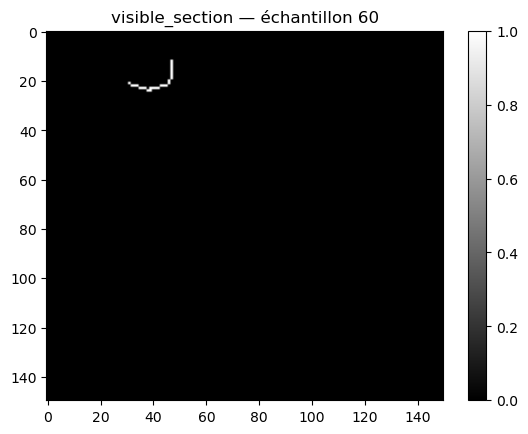

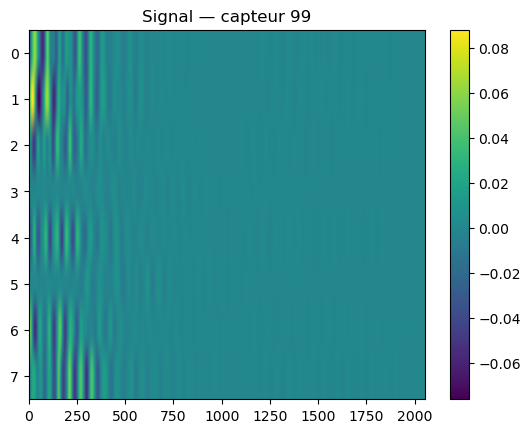

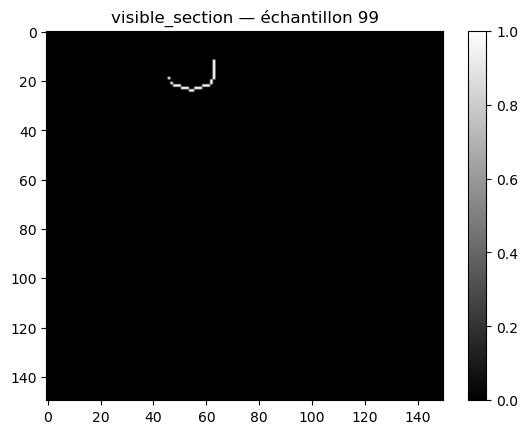

In [6]:
indices = [0, 10, 30, 60, 99]
for idx in indices:
    plt.imshow(X[idx], aspect='auto')
    plt.colorbar()
    plt.title(f"Signal — capteur {idx}")
    plt.show()

    plt.imshow(y[idx], cmap='gray', aspect='auto')
    plt.colorbar()
    plt.title(f"visible_section — échantillon {idx}")
    plt.show()


## (Optionnel) Associer les signaux pour pas qu'il y ai t de conflit avec le code de Maxime

In [7]:
X = X_normalized

# 6) Dataset personalisé

In [8]:
class SignalToImageDataset(Dataset):
    def __init__(self, X, y, augment=False):
        X = np.array(X, dtype=np.float32)  # (N, 9, 801)
        y = np.array(y, dtype=np.float32)  # (N, 150, 150)

        self.X = torch.tensor(X).unsqueeze(1)  # (N, 1, 9, 801)
        self.y = torch.tensor(y).unsqueeze(1)  # (N, 1, 150, 150)
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        y = self.y[idx]

        if self.augment:
            # Bruit gaussien (σ = 1% de l'amplitude normalisée)
            if random.random() > 0.5:
                x = x + torch.randn_like(x) * 0.01

            # Décalage temporel circulaire (±10 samples)
            if random.random() > 0.5:
                shift = random.randint(-10, 10)
                x = torch.roll(x, shift, dims=-1)

            # Flip horizontal (symétrie du réseau de capteurs — physiquement valide)
            if random.random() > 0.5:
                x = torch.flip(x, dims=[-2])  # flip sur l'axe capteurs
                y = torch.flip(y, dims=[-1])  # flip correspondant sur la carte

            # Scaling d'amplitude
            if random.random() > 0.5:
                x = x * random.uniform(0.8, 1.2)

            # Écho artificiel (retard + atténuation)
            if random.random() > 0.7:
                delay = random.randint(5, 20)
                x = x + torch.roll(x, delay, dims=-1) * 0.15

        return x, y

In [9]:
batch_size = 8
BATCH_SIZE = batch_size

# 7) Modèle CNN

In [10]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        
        # ----- Encodeur -----
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),  # ↓

            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),  # ↓

            nn.Conv2d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2)   # ↓
        )
        
        # Taille après encodeur (calcul dynamique)
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 41, 2001)
            out = self.encoder(dummy)
            enc_h, enc_w = out.shape[2], out.shape[3]

        # ----- Décodeur -----
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 8, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.Conv2d(8, 1, kernel_size=3, padding=1),
            # Pas de Sigmoid ici — le modèle retourne des logits (BCEWithLogitsLoss)
        )

        # Taille de sortie cible
        self.output_size = (150, 150)

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        # Interpolation bilinéaire vers la taille cible (plus propre que le crop brutal)
        return F.interpolate(x, size=self.output_size, mode='bilinear', align_corners=False)
    
def pixel_accuracy(outputs, targets, threshold=0.5):
    """
    Calcule l'accuracy pixel par pixel.
    outputs : logits — sigmoid appliqué en interne
    targets : (N, 2250) -> 0 ou 1
    """
    outputs = torch.sigmoid(outputs)
    preds = (outputs >= threshold).float()
    correct = (preds == targets).float().sum()
    total = targets.numel()
    return (correct / total).item()

def show_test_predictions(model, test_loader, device, num_samples=3, threshold=0.5):
    """
    Affiche num_samples prédictions du test set, reshaped en (15,150).
    """
    model.eval()
    shown = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = torch.sigmoid(model(inputs))
            
            # Binarisation selon le seuil
            preds = (outputs >= threshold).float()
            preds=outputs

            for i in range(inputs.size(0)):
                pred_img = preds[i].squeeze().cpu().numpy()
                target_img = targets[i].squeeze().cpu().numpy()

                fig, axes = plt.subplots(1, 2, figsize=(8, 4))
                axes[0].imshow(target_img, cmap="gray")
                axes[0].set_title("Vérité terrain")
                axes[0].axis("off")

                axes[1].imshow(pred_img, cmap="gray")
                axes[1].set_title("Prédiction")
                axes[1].axis("off")

                plt.show()

                shown += 1
                if shown >= num_samples:
                    return

# 7b) Fonction de perte : BCE + Dice Loss

La **Dice Loss** mesure le chevauchement entre la prédiction et la vérité terrain.
Elle est particulièrement adaptée aux données déséquilibrées et force le modèle à bien reconstruire la **forme** complète de l'objet, pas seulement sa position.

`Loss = BCE + Dice`

# 7c) Architecture U-Net avec skip connections

Le U-Net relie chaque niveau de l'encodeur directement au décodeur correspondant via des **skip connections**.
Cela permet de préserver les détails spatiaux fins (forme, contours) qui sont perdus dans le goulot d'étranglement du CNN simple.

Chaque bloc inclut aussi une **BatchNorm** pour stabiliser l'entraînement.

In [11]:
class DoubleConv(nn.Module):
    """Deux convolutions consécutives avec BatchNorm, ReLU et Dropout optionnel."""
    def __init__(self, in_ch, out_ch, dropout_p=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if dropout_p > 0:
            layers.append(nn.Dropout2d(dropout_p))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self, dropout_p=0.1):
        super().__init__()
        # Encodeur (avec dropout pour régularisation sur petit dataset)
        self.enc1 = DoubleConv(1, 32, dropout_p=dropout_p)
        self.enc2 = DoubleConv(32, 64, dropout_p=dropout_p)
        self.enc3 = DoubleConv(64, 128, dropout_p=dropout_p)
        self.pool = nn.MaxPool2d(2)

        # Goulot d'étranglement (dropout pour régulariser la représentation la plus compressée)
        self.bottleneck = DoubleConv(128, 256, dropout_p=0.2)

        # Décodeur (sans dropout)
        self.up3  = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(256, 128)   # 128 (up) + 128 (skip)

        self.up2  = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128, 64)    # 64  (up) + 64  (skip)

        self.up1  = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(64, 32)     # 32  (up) + 32  (skip)

        self.final   = nn.Conv2d(32, 1, kernel_size=1)
        self.output_size = (150, 150)

    def _crop(self, skip, target):
        """Recadre le skip pour correspondre à la taille de target."""
        _, _, h, w = target.shape
        return skip[:, :, :h, :w]

    def forward(self, x):
        # Encodeur + skip connections
        s1 = self.enc1(x)                    # (32, 41, 801)
        s2 = self.enc2(self.pool(s1))        # (64, 20, 400)
        s3 = self.enc3(self.pool(s2))        # (128, 10, 200)

        # Goulot
        b = self.bottleneck(self.pool(s3))   # (256, 5, 100)

        # Décodeur avec skip connections
        d3 = self.up3(b)
        d3 = self.dec3(torch.cat([d3, self._crop(s3, d3)], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, self._crop(s2, d2)], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, self._crop(s1, d1)], dim=1))

        out = self.final(d1)  # logits — pas de Sigmoid

        # Interpolation bilinéaire vers la taille cible
        return F.interpolate(out, size=self.output_size, mode='bilinear', align_corners=False)

In [12]:
def compute_pos_weight(y_array, device):
    """Calcule automatiquement le pos_weight depuis les données."""
    ratio = y_array.mean()
    if ratio == 0:
        return torch.tensor([50.0], device=device)
    pw = (1.0 - ratio) / ratio
    # On plafonne pour éviter des valeurs extrêmes
    pw = float(np.clip(pw, 5.0, 200.0))
    print(f"pos_weight calculé : {pw:.1f}  (ratio positifs = {ratio*100:.2f}%)")
    return torch.tensor([pw], device=device)
    
class BCEDiceLoss(nn.Module):
    """
    Combinaison BCE pondérée + Dice Loss.
    Les modèles doivent retourner des logits (pas de Sigmoid en sortie).
    """
    def __init__(self, pos_weight, bce_weight=0.4):
        super().__init__()
        self.bce_weight = bce_weight
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)

        # Dice sur les probabilités (après sigmoid)
        probs = torch.sigmoid(logits)
        smooth = 1e-6
        p = probs.reshape(probs.size(0), -1)
        t = targets.reshape(targets.size(0), -1)
        intersection = (p * t).sum(dim=1)
        dice_loss = 1 - (2 * intersection + smooth) / (p.sum(dim=1) + t.sum(dim=1) + smooth)
        dice_loss = dice_loss.mean()

        return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice_loss
pos_weight = compute_pos_weight(y, device)

pos_weight calculé : 200.0  (ratio positifs = 0.11%)


In [13]:
class FocalDiceLoss(nn.Module):
    """
    Focal Loss + Dice Loss — conçu pour les classes très déséquilibrées (< 1% positifs).

    Focal Loss : down-pondère les exemples faciles (pixels à 0 bien classés) via (1-p_t)^γ,
    forçant le réseau à se concentrer sur les positifs difficiles.
    alpha pondère les positifs (> 0.5 recommandé si très peu de positifs).

    Les modèles retournent des logits — pas de Sigmoid en sortie.
    """
    def __init__(self, alpha=0.75, gamma=2.0, dice_weight=0.5):
        super().__init__()
        self.alpha       = alpha        # poids des positifs (0 < alpha < 1)
        self.gamma       = gamma        # facteur de focalisation (2 = standard)
        self.dice_weight = dice_weight  # part de la Dice dans la loss totale

    def forward(self, logits, targets):
        # ── Focal Loss ───────────────────────────────────────────────────────
        bce     = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t     = torch.exp(-bce)
        # alpha_t : alpha pour les positifs, (1-alpha) pour les négatifs
        alpha_t    = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_loss = (alpha_t * (1 - p_t) ** self.gamma * bce).mean()

        # ── Dice Loss (sur probabilités) ─────────────────────────────────────
        probs  = torch.sigmoid(logits)
        smooth = 1e-6
        p_flat = probs.reshape(probs.size(0), -1)
        t_flat = targets.reshape(targets.size(0), -1)
        inter  = (p_flat * t_flat).sum(dim=1)
        dice_loss = (1 - (2 * inter + smooth) / (p_flat.sum(dim=1) + t_flat.sum(dim=1) + smooth)).mean()

        return (1 - self.dice_weight) * focal_loss + self.dice_weight * dice_loss


# 8) Fonction d'entrainement avec découpage

In [14]:
def train_and_validate(X, y, model_class, epochs=200, batch_size=8, lr=5e-4, patience=30):
    # Garantir que X et y sont des numpy arrays (résiste à y = list_outputs)
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    torch.manual_seed(42)
    random.seed(42)
    np.random.seed(42)

    # Dataset de base (sans augmentation) pour val/test
    full_dataset = SignalToImageDataset(X, y, augment=False)
    # Split 65/15/20 adapté aux ~380 échantillons disponibles
    n = len(full_dataset)
    n_train = int(0.65 * n)
    n_val   = int(0.15 * n)
    n_test  = n - n_train - n_val
    lengths = [n_train, n_val, n_test]
    train_set, val_set, test_set = random_split(full_dataset, lengths)

    # Dataset d'entraînement avec augmentation
    train_dataset_aug = SignalToImageDataset(
        X[list(train_set.indices)],
        y[list(train_set.indices)],
        augment=True
    )

    train_loader = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_set,  batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_set, batch_size=batch_size, shuffle=False)

    model = model_class()
    #device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    device = torch.device("cpu")
    model.to(device)

    #criterion = FocalDiceLoss(alpha=0.75, gamma=2.0, dice_weight=0.5)
    criterion = BCEDiceLoss(pos_weight=pos_weight, bce_weight=0.4)
    # weight_decay=1e-4 pour régularisation L2
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    # Scheduler : divise le LR par 2 si la val_loss stagne pendant 10 epochs
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
    )

    # Early stopping vars
    best_val_loss = float("inf")
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [],  "val_acc": [],
        "lr": []
    }

    for epoch in range(epochs):
        # ---- Train ----
        model.train()
        train_loss_sum = 0.0
        train_acc_sum  = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss_sum += loss.item()
            train_acc_sum  += pixel_accuracy(outputs, targets)

        # ---- Validation ----
        model.eval()
        val_loss_sum = 0.0
        val_acc_sum  = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss_sum += loss.item()
                val_acc_sum  += pixel_accuracy(outputs, targets)

        train_loss = train_loss_sum / len(train_loader)
        train_acc  = train_acc_sum  / len(train_loader)
        val_loss   = val_loss_sum   / len(val_loader)
        val_acc    = val_acc_sum    / len(val_loader)
        current_lr = optimizer.param_groups[0]['lr']

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        # Mise à jour du scheduler
        scheduler.step(val_loss)

        print(f"Epoch {epoch+1}/{epochs} "
              f"| Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} "
              f"| Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} "
              f"| LR: {current_lr:.2e}")

        # ---- Early stopping ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping à l'epoch {epoch+1}")
                break

    # ---- Restore best model ----
    model.load_state_dict(best_model_wts)

    # ---- Test set evaluation ----
    model.eval()
    test_loss_sum = 0.0
    test_acc_sum  = 0.0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_loss_sum += loss.item()
            test_acc_sum  += pixel_accuracy(outputs, targets)

    test_loss = test_loss_sum / len(test_loader)
    test_acc  = test_acc_sum  / len(test_loader)
    print(f"\nTest Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

    # ---- Courbes ----
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(history["train_loss"], label="Train Loss")
    axes[0].plot(history["val_loss"],   label="Val Loss")
    axes[0].axhline(y=test_loss, color='r', linestyle='--', label=f"Test Loss ({test_loss:.4f})")
    axes[0].set_xlabel("Epochs"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].set_title("Loss vs Epochs")

    axes[1].plot(history["train_acc"], label="Train Acc")
    axes[1].plot(history["val_acc"],   label="Val Acc")
    axes[1].axhline(y=test_acc, color='r', linestyle='--', label=f"Test Acc ({test_acc:.4f})")
    axes[1].set_xlabel("Epochs"); axes[1].set_ylabel("Accuracy")
    axes[1].legend(); axes[1].set_title("Accuracy vs Epochs")

    axes[2].plot(history["lr"])
    axes[2].set_xlabel("Epochs"); axes[2].set_ylabel("Learning Rate")
    axes[2].set_yscale("log"); axes[2].set_title("Learning Rate (scheduler)")

    plt.tight_layout()
    plt.show()

    # ---- Sauvegarde ----
    torch.save(model.state_dict(), "model_unet_BCE.pth")
    print("Modèle sauvegardé dans model_unet_finale.pth")

    return model, train_loader, val_loader, test_loader

# 9) Lancement de l'entrainement

Epoch 1/200 | Train Loss: 0.8055 Acc: 0.8565 | Val Loss: 0.7686 Acc: 0.8894 | LR: 5.00e-04
Epoch 2/200 | Train Loss: 0.7473 Acc: 0.9050 | Val Loss: 0.7355 Acc: 0.9112 | LR: 5.00e-04
Epoch 3/200 | Train Loss: 0.7233 Acc: 0.9179 | Val Loss: 0.7153 Acc: 0.9126 | LR: 5.00e-04
Epoch 4/200 | Train Loss: 0.7088 Acc: 0.9229 | Val Loss: 0.7061 Acc: 0.9218 | LR: 5.00e-04
Epoch 5/200 | Train Loss: 0.7017 Acc: 0.9266 | Val Loss: 0.6973 Acc: 0.9213 | LR: 5.00e-04
Epoch 6/200 | Train Loss: 0.6945 Acc: 0.9291 | Val Loss: 0.6928 Acc: 0.9263 | LR: 5.00e-04
Epoch 7/200 | Train Loss: 0.6902 Acc: 0.9318 | Val Loss: 0.7023 Acc: 0.9264 | LR: 5.00e-04
Epoch 8/200 | Train Loss: 0.6876 Acc: 0.9325 | Val Loss: 0.6922 Acc: 0.9336 | LR: 5.00e-04
Epoch 9/200 | Train Loss: 0.6844 Acc: 0.9354 | Val Loss: 0.6893 Acc: 0.9438 | LR: 5.00e-04
Epoch 10/200 | Train Loss: 0.6809 Acc: 0.9376 | Val Loss: 0.6811 Acc: 0.9351 | LR: 5.00e-04
Epoch 11/200 | Train Loss: 0.6770 Acc: 0.9397 | Val Loss: 0.6801 Acc: 0.9381 | LR: 5.00e-

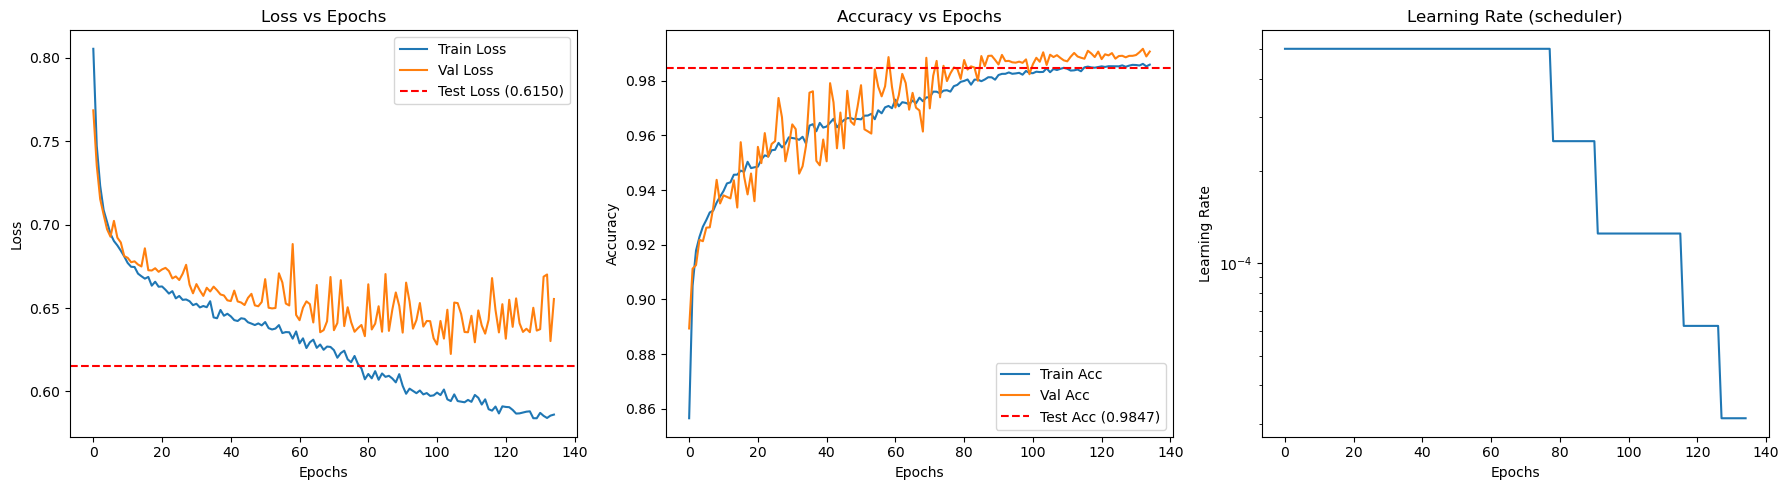

Modèle sauvegardé dans model_unet_finale.pth
model entrainé


In [15]:
if mode_entrainement :
    model, train_loader, val_loader, test_loader = train_and_validate(X, y, UNet, batch_size=2)
    print('model entrainé')
else :
    print('pas de mode entrainement')

# 9b) Recharger le modèle sans réentraîner

Exécuter cette cellule si le modèle a déjà été entraîné et sauvegardé (`model_cnn.pth` existe).

In [26]:
def load_model(model_class, path, device):
    model = model_class().to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    print(f"Modèle chargé depuis {path}")
    return model
device = torch.device('cpu')
dataset = SignalToImageDataset(X, y)
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)
n = len(dataset)
n_train = int(0.65 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val
train_set, val_set, test_set = random_split(dataset, [n_train, n_val, n_test])
train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=8, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=8, shuffle=False)
# Décommenter si besoin :
#model_cnn  = load_model(SimpleCNN, "model_simplecnn.pth", device)

model_unet = load_model(UNet,   "model_unet_BCE.pth",      device)
model = model_unet

Modèle chargé depuis model_unet_BCE.pth


# 10) Présentation des résultats

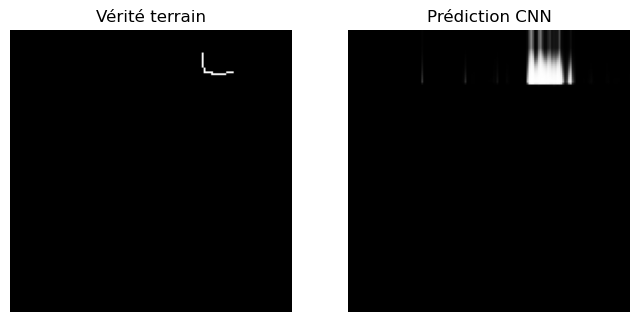

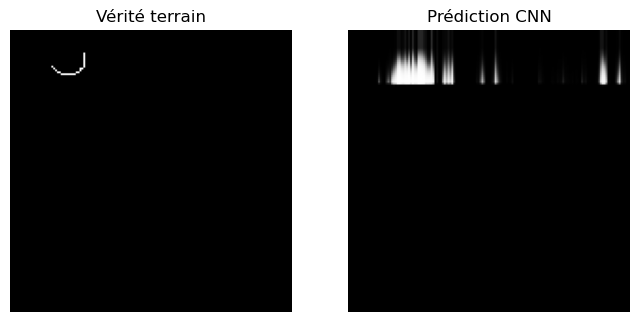

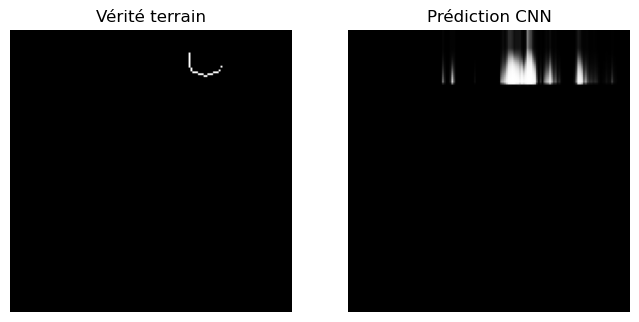

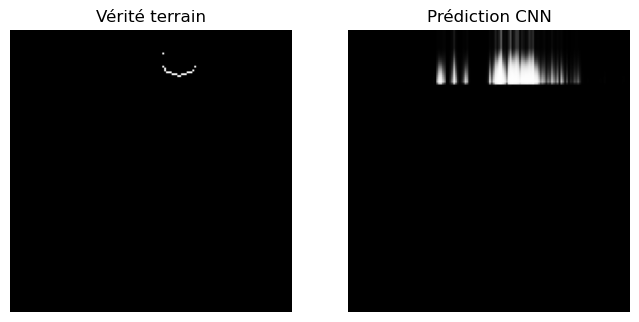

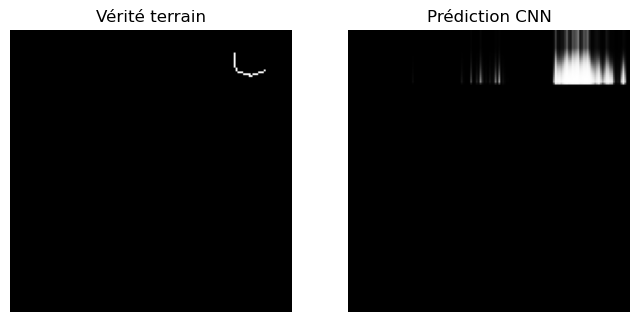

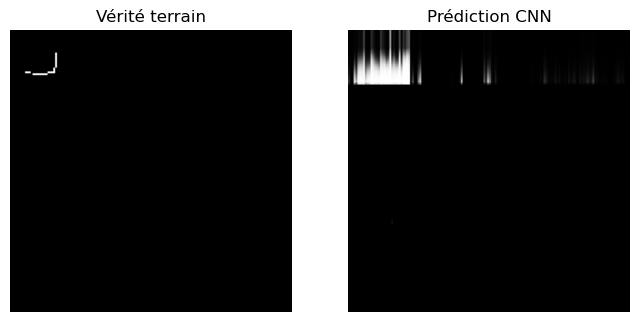

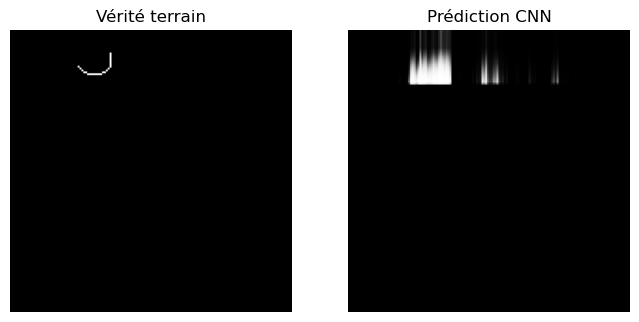

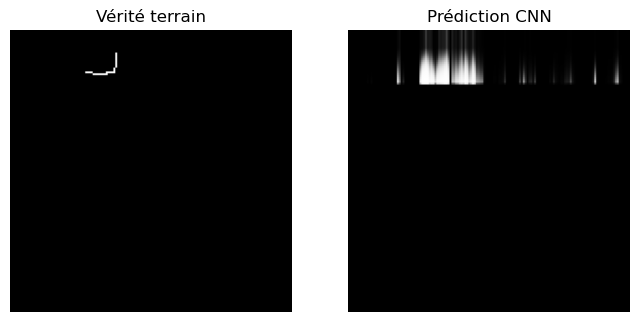

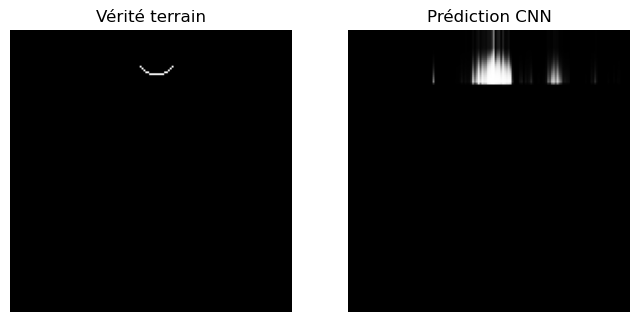

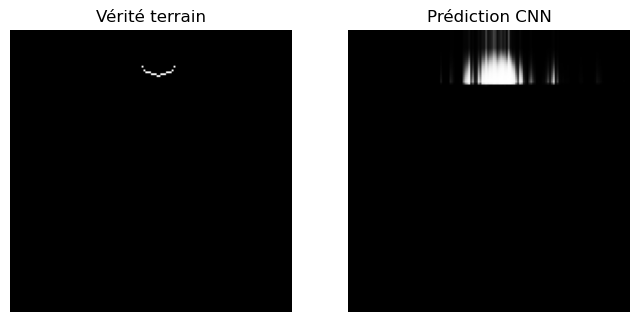

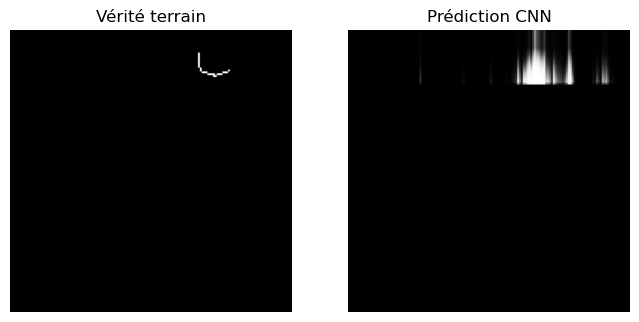

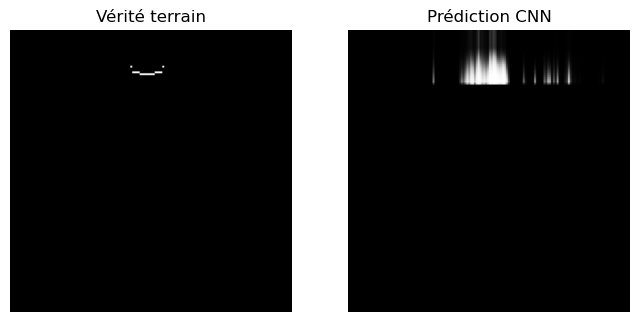

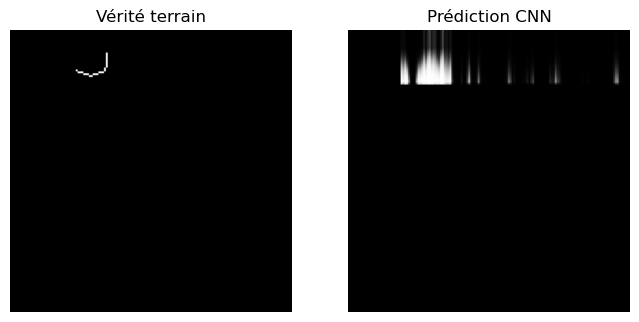

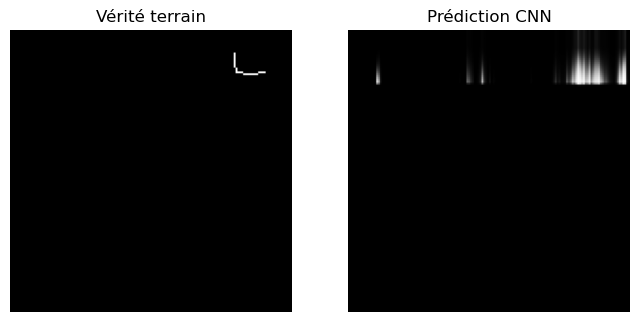

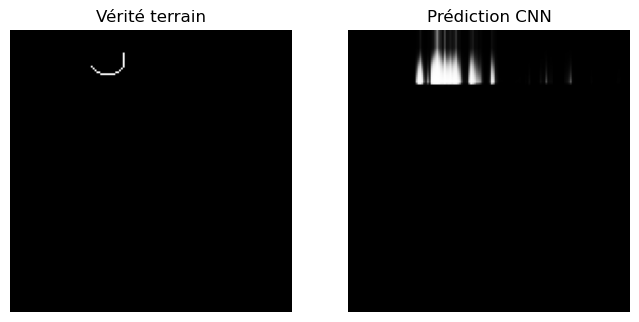

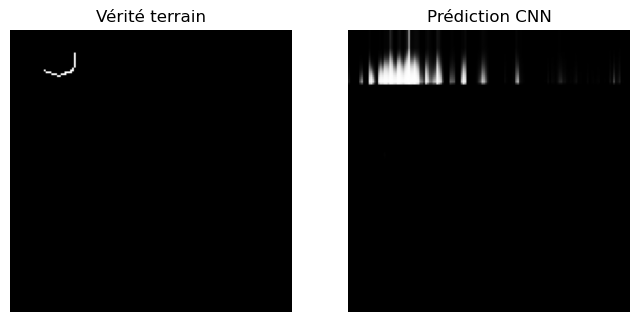

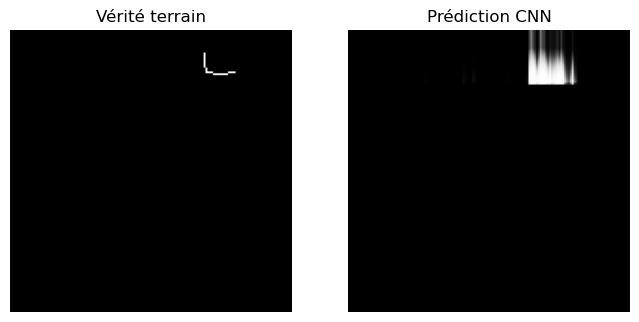

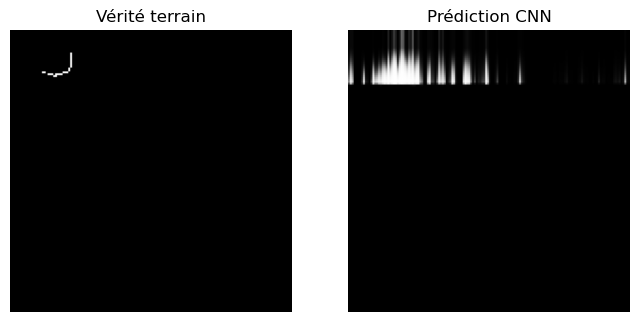

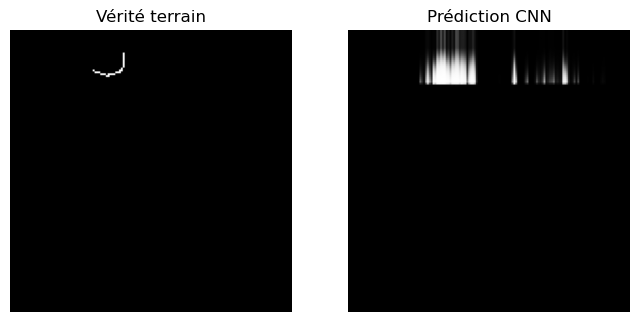

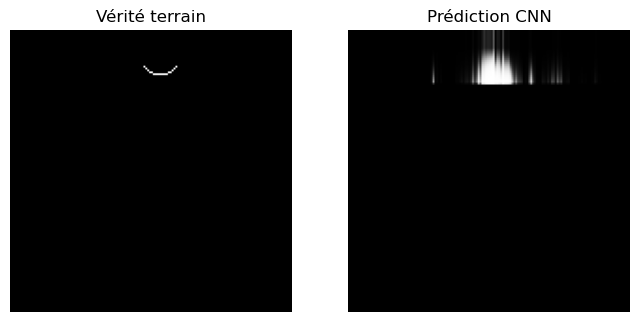

In [27]:
def show_predictions(model, loader, device, num_samples=3):
    model.eval()
    shown = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = torch.sigmoid(model(inputs))
            preds = outputs.cpu().numpy()

            for i in range(inputs.size(0)):
                fig, axes = plt.subplots(1, 2, figsize=(8, 4))
                axes[0].imshow(targets[i].cpu().squeeze(), cmap="gray")
                axes[0].set_title("Vérité terrain")
                axes[0].axis("off")

                axes[1].imshow(preds[i].squeeze(), cmap="gray")
                axes[1].set_title("Prédiction CNN")
                axes[1].axis("off")
                plt.show()

                shown += 1
                if shown >= num_samples:
                    return
                
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
show_predictions(model_unet, test_loader, device, num_samples=20)

# 11) Diagnostic des prédictions

## 11a) Distribution des valeurs prédites

Vérifie si le modèle prédit des valeurs variées ou s'effondre vers 0 ou 1.

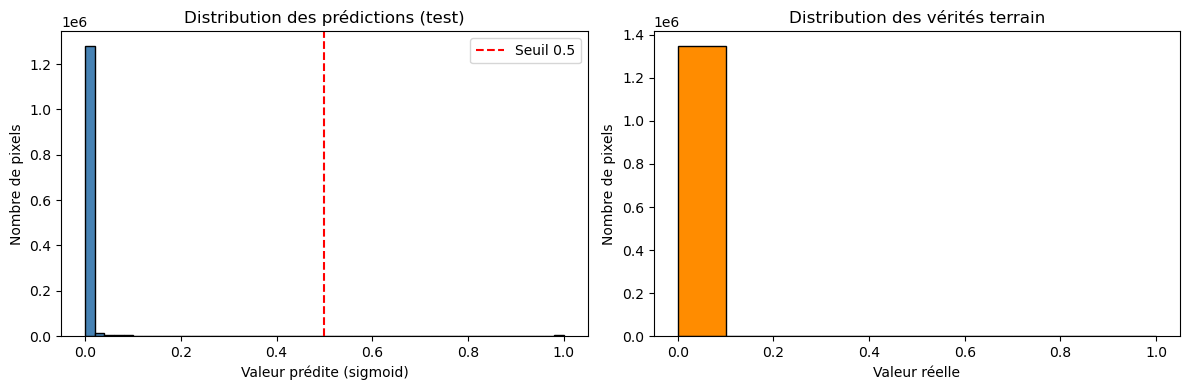

Ratio de pixels positifs (=1) dans la vérité terrain : 0.0011 (0.11%)
Moyenne des prédictions (test) : 0.0184
Std des prédictions (test)     : 0.1115


In [28]:
# --- Collecte sur le VAL set (pour calibrer le seuil sans biais) ---
val_preds_all   = []
val_targets_all = []

model.eval()
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = torch.sigmoid(model(inputs))
        val_preds_all.append(outputs.cpu().numpy().flatten())
        val_targets_all.append(targets.cpu().numpy().flatten())

val_preds_all   = np.concatenate(val_preds_all)
val_targets_all = np.concatenate(val_targets_all)

# --- Collecte sur le TEST set (pour évaluation finale uniquement) ---
all_preds   = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = torch.sigmoid(model(inputs))
        all_preds.append(outputs.cpu().numpy().flatten())
        all_targets.append(targets.cpu().numpy().flatten())

all_preds   = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

# Histogramme des valeurs prédites (test)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(all_preds, bins=50, color='steelblue', edgecolor='black')
plt.xlabel("Valeur prédite (sigmoid)")
plt.ylabel("Nombre de pixels")
plt.title("Distribution des prédictions (test)")
plt.axvline(x=0.5, color='red', linestyle='--', label="Seuil 0.5")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(all_targets, bins=10, color='darkorange', edgecolor='black')
plt.xlabel("Valeur réelle")
plt.ylabel("Nombre de pixels")
plt.title("Distribution des vérités terrain")

plt.tight_layout()
plt.show()

ratio_positifs = all_targets.mean()
print(f"Ratio de pixels positifs (=1) dans la vérité terrain : {ratio_positifs:.4f} ({ratio_positifs*100:.2f}%)")
print(f"Moyenne des prédictions (test) : {all_preds.mean():.4f}")
print(f"Std des prédictions (test)     : {all_preds.std():.4f}")

## 11b) Métriques de segmentation : Précision, Rappel, F1, IoU

La **pixel accuracy** seule est trompeuse quand les classes sont déséquilibrées.
- **Précision** : parmi les pixels prédits à 1, combien sont vrais ?
- **Rappel** : parmi les pixels réels à 1, combien sont détectés ?
- **F1** : moyenne harmonique précision/rappel
- **IoU** (Intersection over Union) : métrique standard en segmentation

Seuil optimal (calibré sur val set) : 0.88  →  F1_val = 0.1159

=== Métriques sur le test set (seuil calibré sur val set) ===
  Accuracy    : 0.9914
  Précision   : 0.0674
  Rappel      : 0.5380
  F1          : 0.1198
  IoU         : 0.0637


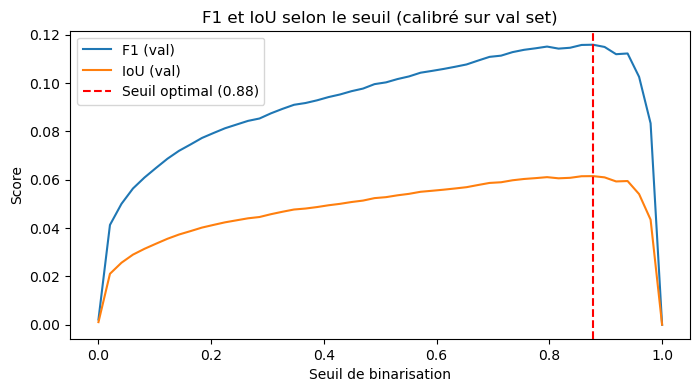

In [29]:
def compute_metrics(preds_prob, targets, threshold=0.5):
    preds = (preds_prob >= threshold).astype(float)

    TP = ((preds == 1) & (targets == 1)).sum()
    FP = ((preds == 1) & (targets == 0)).sum()
    FN = ((preds == 0) & (targets == 1)).sum()
    TN = ((preds == 0) & (targets == 0)).sum()

    precision = TP / (TP + FP + 1e-8)
    recall    = TP / (TP + FN + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)
    iou       = TP / (TP + FP + FN + 1e-8)
    accuracy  = (TP + TN) / (TP + FP + FN + TN + 1e-8)

    return {"Accuracy": accuracy, "Précision": precision, "Rappel": recall, "F1": f1, "IoU": iou}

# --- Calibration du seuil sur le VAL set (évite le data leakage) ---
thresholds    = np.linspace(0, 1, 50)
val_f1_scores = [compute_metrics(val_preds_all, val_targets_all, t)["F1"]  for t in thresholds]
val_iou_scores= [compute_metrics(val_preds_all, val_targets_all, t)["IoU"] for t in thresholds]

best_t = thresholds[np.argmax(val_f1_scores)]
print(f"Seuil optimal (calibré sur val set) : {best_t:.2f}  →  F1_val = {max(val_f1_scores):.4f}")

# --- Évaluation finale sur le TEST set avec le seuil calibré ---
metrics = compute_metrics(all_preds, all_targets, threshold=best_t)
print("\n=== Métriques sur le test set (seuil calibré sur val set) ===")
for name, val in metrics.items():
    print(f"  {name:<12}: {val:.4f}")

# Courbe F1 et IoU sur le val set
plt.figure(figsize=(8, 4))
plt.plot(thresholds, val_f1_scores,  label="F1 (val)")
plt.plot(thresholds, val_iou_scores, label="IoU (val)")
plt.axvline(x=best_t, color='red', linestyle='--', label=f"Seuil optimal ({best_t:.2f})")
plt.xlabel("Seuil de binarisation")
plt.ylabel("Score")
plt.title("F1 et IoU selon le seuil (calibré sur val set)")
plt.legend()
plt.show()

## Post-traitement morphologique (Option 3)

L'érosion morphologique **réduit les faux positifs** en supprimant les prédictions isolées.
Principe : un pixel prédit à 1 n'est conservé que si ses voisins immédiats sont aussi à 1.
Ça élimine le "bruit" de pixels positifs éparpillés tout en préservant les régions cohérentes.

- `iterations=1` : érosion légère (supprime les pixels isolés)
- `iterations=2` : érosion forte (ne conserve que les zones compactes)


=== Comparaison sans / avec érosion morphologique (test set) ===

Métrique       Sans érosion     Érosion ×1     Érosion ×2
--------------------------------------------------------
Accuracy             0.9914         0.9951         0.9970
Précision            0.0674         0.0882         0.1073
Rappel               0.5380         0.3744         0.2430
F1                   0.1198         0.1428         0.1489
IoU                  0.0637         0.0769         0.0804
--------------------------------------------------------
(seuil : 0.88 pour sans-érosion, 0.5 appliqué sur binaire érodé)

--- Exemple visuel : effet de l'érosion sur une prédiction ---


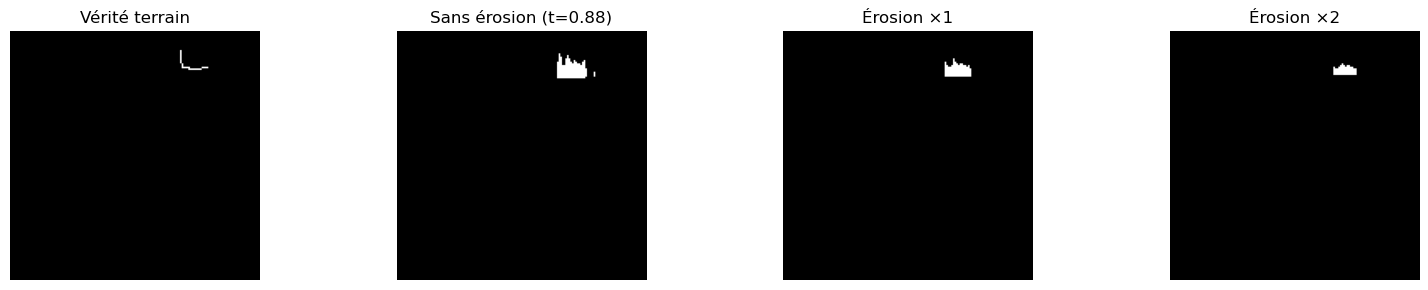

In [30]:
def erode_batch(probs_flat, targets_flat, img_shape, threshold, iterations=1):
    """
    Applique l'érosion image par image puis recalcule les métriques.
    probs_flat   : (N_pixels,) — probabilités aplaties
    targets_flat : (N_pixels,) — vérités terrain aplaties
    img_shape    : (H, W) de chaque image (ex. (150, 150))
    """
    n_pixels = img_shape[0] * img_shape[1]
    n_imgs   = len(probs_flat) // n_pixels

    eroded_preds = []
    for k in range(n_imgs):
        pred_2d = (probs_flat[k*n_pixels:(k+1)*n_pixels] >= threshold).reshape(img_shape)
        pred_eroded = binary_erosion(pred_2d, iterations=iterations).astype(float)
        eroded_preds.append(pred_eroded.flatten())

    eroded_flat = np.concatenate(eroded_preds)
    return eroded_flat


IMG_SHAPE = (150, 150)

print("=== Comparaison sans / avec érosion morphologique (test set) ===\n")
print(f"{'Métrique':<12} {'Sans érosion':>14} {'Érosion ×1':>14} {'Érosion ×2':>14}")
print("-" * 56)

for metric in ["Accuracy", "Précision", "Rappel", "F1", "IoU"]:
    m0 = compute_metrics(all_preds, all_targets, best_t)[metric]
    eroded1 = erode_batch(all_preds, all_targets, IMG_SHAPE, best_t, iterations=1)
    m1 = compute_metrics(eroded1,   all_targets, threshold=0.5)[metric]
    eroded2 = erode_batch(all_preds, all_targets, IMG_SHAPE, best_t, iterations=2)
    m2 = compute_metrics(eroded2,   all_targets, threshold=0.5)[metric]
    print(f"{metric:<12} {m0:>14.4f} {m1:>14.4f} {m2:>14.4f}")

print("-" * 56)
print(f"(seuil : {best_t:.2f} pour sans-érosion, 0.5 appliqué sur binaire érodé)")

# Visualisation d'un exemple : avant / après érosion
print("\n--- Exemple visuel : effet de l'érosion sur une prédiction ---")
sample_prob = all_preds[:IMG_SHAPE[0]*IMG_SHAPE[1]].reshape(IMG_SHAPE)
sample_bin  = (sample_prob >= best_t).astype(float)
sample_e1   = binary_erosion(sample_bin, iterations=1).astype(float)
sample_e2   = binary_erosion(sample_bin, iterations=2).astype(float)
sample_gt   = all_targets[:IMG_SHAPE[0]*IMG_SHAPE[1]].reshape(IMG_SHAPE)

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, img, title in zip(axes,
    [sample_gt, sample_bin, sample_e1, sample_e2],
    ["Vérité terrain", f"Sans érosion (t={best_t:.2f})", "Érosion ×1", "Érosion ×2"]):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 11c) Visualisation côte à côte avec superposition des erreurs

Rouge = faux positifs (prédit 1, réel 0) | Bleu = faux négatifs (prédit 0, réel 1)

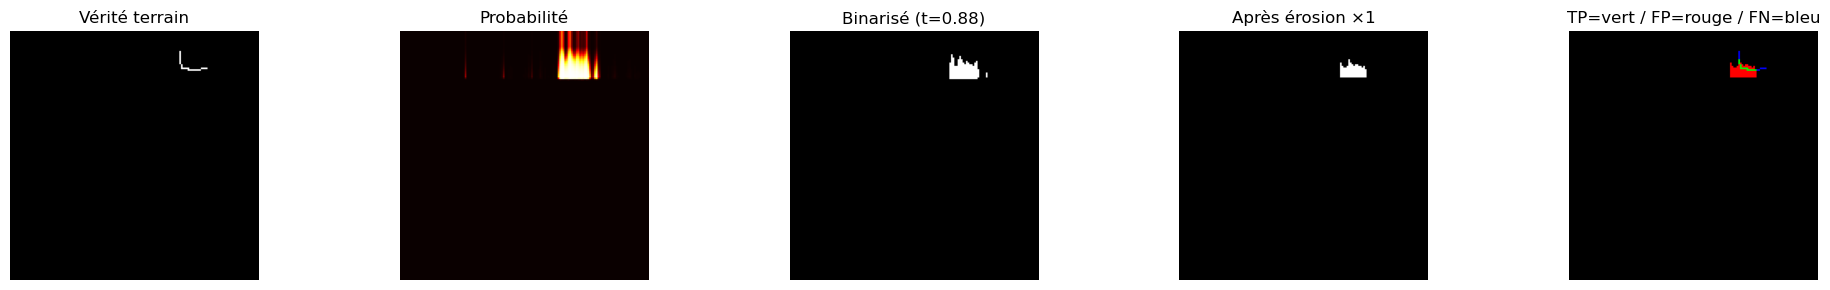

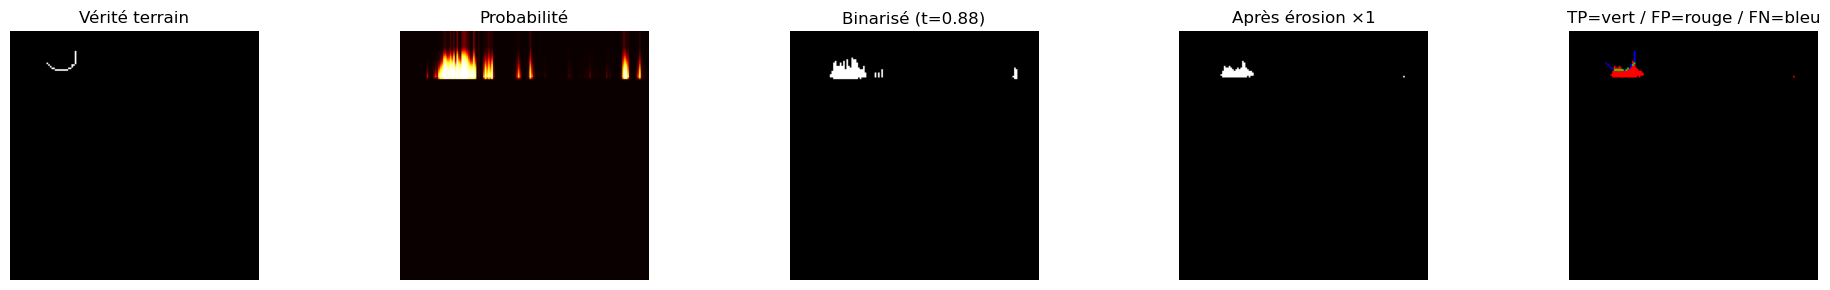

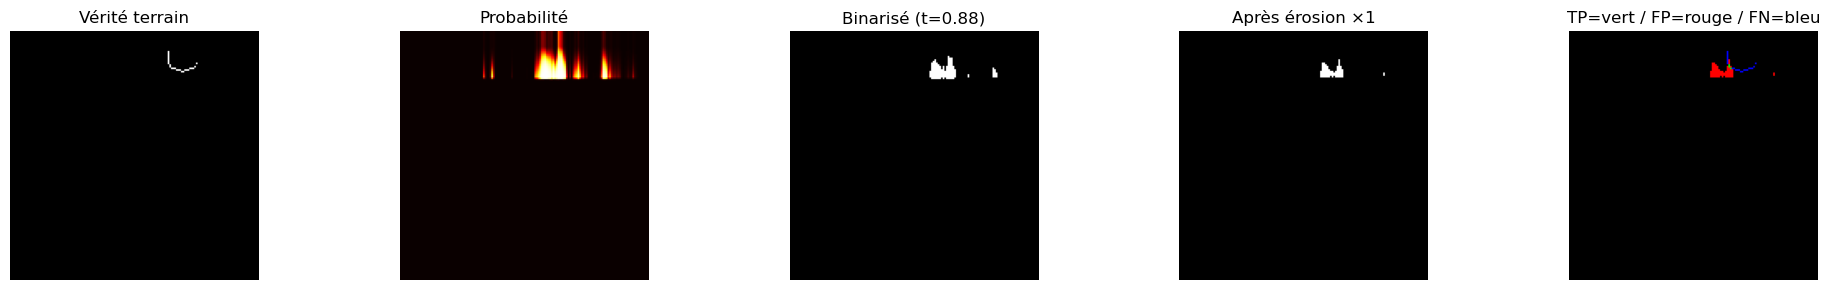

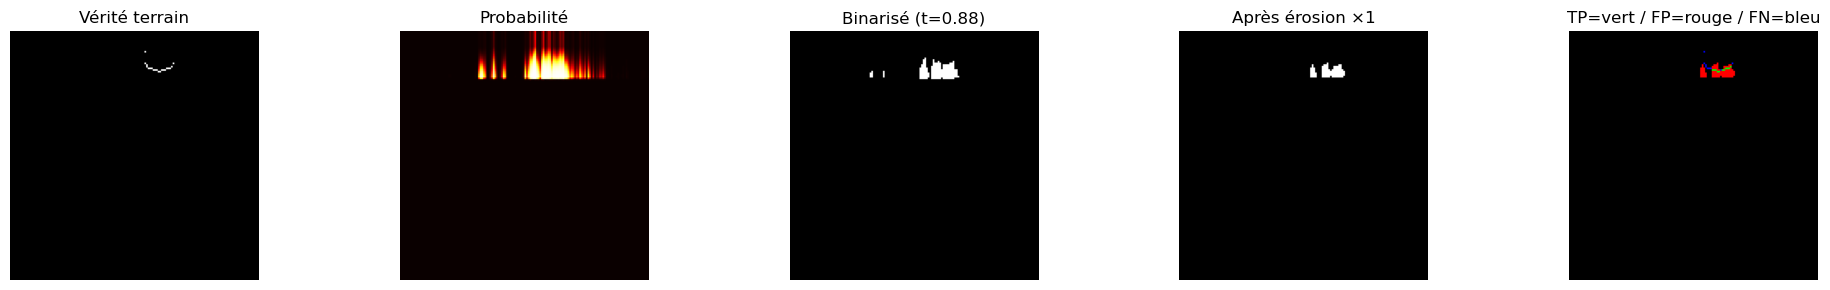

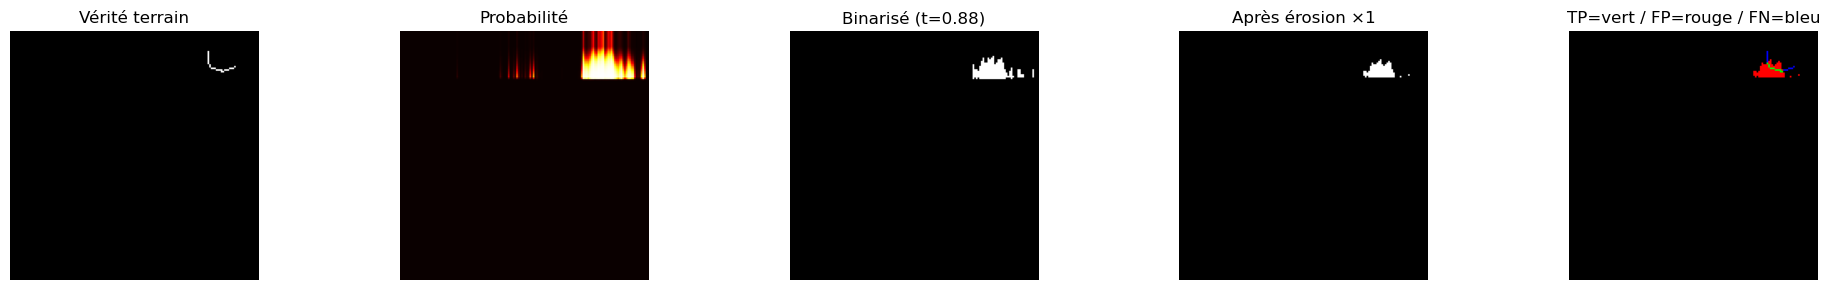

In [31]:
def show_diagnostic(model, loader, device, num_samples=5, threshold=0.5, erosion_iter=1):
    """
    Affiche 5 colonnes : vérité terrain / probabilité / binarisé / érodé / carte d'erreurs.
    erosion_iter : nombre d'itérations d'érosion (0 = désactivé)
    """
    model.eval()
    shown = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = torch.sigmoid(model(inputs))

            for i in range(inputs.size(0)):
                pred_prob = outputs[i].squeeze().cpu().numpy()
                pred_bin  = (pred_prob >= threshold).astype(float)
                pred_post = binary_erosion(pred_bin, iterations=erosion_iter).astype(float) \
                            if erosion_iter > 0 else pred_bin
                target    = targets[i].squeeze().cpu().numpy()

                # Carte d'erreurs sur la prédiction post-traitée
                error_map = np.zeros((*target.shape, 3))
                error_map[(pred_post == 1) & (target == 1)] = [0, 1, 0]   # TP vert
                error_map[(pred_post == 1) & (target == 0)] = [1, 0, 0]   # FP rouge
                error_map[(pred_post == 0) & (target == 1)] = [0, 0, 1]   # FN bleu

                fig, axes = plt.subplots(1, 5, figsize=(20, 3))
                axes[0].imshow(target,    cmap="gray", vmin=0, vmax=1)
                axes[0].set_title("Vérité terrain")
                axes[1].imshow(pred_prob, cmap="hot",  vmin=0, vmax=1)
                axes[1].set_title("Probabilité")
                axes[2].imshow(pred_bin,  cmap="gray", vmin=0, vmax=1)
                axes[2].set_title(f"Binarisé (t={threshold:.2f})")
                axes[3].imshow(pred_post, cmap="gray", vmin=0, vmax=1)
                axes[3].set_title(f"Après érosion ×{erosion_iter}")
                axes[4].imshow(error_map)
                axes[4].set_title("TP=vert / FP=rouge / FN=bleu")
                for ax in axes:
                    ax.axis("off")
                plt.tight_layout()
                plt.show()

                shown += 1
                if shown >= num_samples:
                    return

show_diagnostic(model, test_loader, device, num_samples=5, threshold=best_t, erosion_iter=1)

## 12) Pipeline en cascade : UNet1D → Y-Net

Le Y-Net prend **deux entrées** :
- Les signaux bruts `(9, 801)` — Encodeur I
- La prédiction grossière du UNet1D `(1, 150, 150)` — Encodeur II

Le UNet1D est d'abord entraîné seul (étape précédente),
puis ses poids sont **figés** pendant l'entraînement du Y-Net.
Le Y-Net apprend uniquement à **affiner** la sortie du premier réseau.

```
Signaux (9,801) ──────────────────────────────────► Encodeur I ──┐
                 └──► UNet1D (figé) ──► carte grossière ──► Encodeur II ──┤
                                                                  └──► Décodeur ──► carte affinée
```


In [32]:
class DoubleConv1D(nn.Module):
    def __init__(self, in_ch, out_ch, k=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, k, padding=k//2, bias=False),
            nn.BatchNorm1d(out_ch), nn.ReLU(inplace=True),
            nn.Conv1d(out_ch, out_ch, k, padding=k//2, bias=False),
            nn.BatchNorm1d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class DoubleConv2D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class YNetCascade(nn.Module):
    """
    Y-Net prenant en entrée :
      - x_sig : signaux bruts (B, 8, 2056)
      - x_coarse : prédiction grossière du UNet1D (B, 1, 150, 150)
    Retourne des logits (B, 1, 150, 150).
    """
    def __init__(self):
        super().__init__()

        # ── Encodeur I : signaux bruts 1D ─────────────────────────────────
        self.e1_1 = DoubleConv1D(8,  32)
        self.e1_2 = DoubleConv1D(32, 64)
        self.e1_3 = DoubleConv1D(64, 128)
        self.pool1 = nn.MaxPool1d(2)

        # ── Encodeur II : carte grossière 2D ──────────────────────────────
        self.e2_1 = DoubleConv2D(1,  32)
        self.e2_2 = DoubleConv2D(32, 64)
        self.e2_3 = DoubleConv2D(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        # ── Décodeur partagé ──────────────────────────────────────────────
        # Chaque étage : upsample + skip enc2 + skip enc1 projeté en 2D
        self.up3  = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec3 = DoubleConv2D(64 + 64 + 64, 64)

        self.up2  = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec2 = DoubleConv2D(32 + 32 + 32, 32)

        self.up1  = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.dec1 = DoubleConv2D(16, 16)

        self.final = nn.Conv2d(16, 1, kernel_size=1)

    def _1d_to_2d(self, feat_1d, h, w):
        """Projette un skip 1D (B, C, L) en feature map 2D (B, C, H, W)."""
        # On broadcast sur la hauteur puis on interpole à la bonne taille
        x = feat_1d.unsqueeze(2).expand(-1, -1, h, -1)   # (B, C, H, L)
        return F.interpolate(x, size=(h, w), mode='bilinear', align_corners=False)

    def forward(self, x_sig, x_coarse):
        # ── Encodeur I ────────────────────────────────────────────────────
        s1_1 = self.e1_1(x_sig)                   # (B, 32,  801)
        s1_2 = self.e1_2(self.pool1(s1_1))        # (B, 64,  400)
        s1_3 = self.e1_3(self.pool1(s1_2))        # (B, 128, 200)

        # ── Encodeur II ───────────────────────────────────────────────────
        s2_1 = self.e2_1(x_coarse)                # (B, 32,  150, 150)
        s2_2 = self.e2_2(self.pool2(s2_1))        # (B, 64,   75,  75)
        s2_3 = self.e2_3(self.pool2(s2_2))        # (B, 128,  37,  37)

        # Goulot : on part de s2_3 (le plus compressé de l'enc II)
        d = self.up3(s2_3)                         # (B, 64, 75, 75)
        sk2 = F.interpolate(s2_2, d.shape[2:], mode='bilinear', align_corners=False)
        sk1 = self._1d_to_2d(s1_2, d.shape[2], d.shape[3])
        d = self.dec3(torch.cat([d, sk2, sk1], dim=1))

        d = self.up2(d)                            # (B, 32, 150, 150)
        sk2 = F.interpolate(s2_1, d.shape[2:], mode='bilinear', align_corners=False)
        sk1 = self._1d_to_2d(s1_1, d.shape[2], d.shape[3])
        d = self.dec2(torch.cat([d, sk2, sk1], dim=1))

        d = self.up1(d)
        d = self.dec1(d)
        out = self.final(d)
        return F.interpolate(out, size=(150, 150), mode='bilinear', align_corners=False)


# Vérification des shapes
with torch.no_grad():
    _sig    = torch.zeros(2, 8, 801)
    _coarse = torch.zeros(2, 1, 150, 150)
    print('YNetCascade output shape :', YNetCascade()(_sig, _coarse).shape)


YNetCascade output shape : torch.Size([2, 1, 150, 150])


### 18b) Dataset cascade

Le dataset cascade génère à la volée la prédiction grossière
du UNet1D (figé) pour alimenter l'Encodeur II du Y-Net.


In [33]:
full_dataset = SignalToImageDataset(X, y, augment=False)
# Split 65/15/20 adapté aux ~380 échantillons disponibles
n = len(full_dataset)
n_train = int(0.65 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val
lengths = [n_train, n_val, n_test]
train_set, val_set, test_set = random_split(full_dataset, lengths)
# Dataset d'entraînement avec augmentation
train_dataset_aug = SignalToImageDataset(
        X[list(train_set.indices)],
        y[list(train_set.indices)],
        augment=True
)

In [34]:
class CascadeDataset(Dataset):
    """
    Dataset pour le Y-Net cascade.
    Utilise la reconstruction physique réelle (sub[1] du .mat)
    comme Encodeur II — plus besoin de la générer depuis le UNet1D.

    Retourne des triplets (x_sig, x_bf, y) :
      x_sig : signaux bruts    (8, 2056)
      x_bf  : recons. physique (1, 150, 150)
      y     : carte cible      (1, 150, 150)
    """
    def __init__(self, base_dataset, unet_model, device):
        self.ds     = base_dataset
        self.model  = unet_model.eval()
        self.device = device

    def __len__(self): return len(self.ds)

    def __getitem__(self, idx):
        x, y = self.ds[idx]
        with torch.no_grad():
            x_pred = torch.sigmoid(
                self.model(x.unsqueeze(0).to(self.device))
            ).squeeze(0).cpu()   # (1, 150, 150)
        return x, x_pred, y


# Loaders cascade — utilisent la reconstruction physique réelle
casc_train_loader = DataLoader(
    CascadeDataset(train_dataset_aug,model_unet, device), batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)
casc_val_loader = DataLoader(
    CascadeDataset(val_set,model_unet, device), batch_size=BATCH_SIZE, shuffle=False
)
casc_test_loader = DataLoader(
    CascadeDataset(test_set,model_unet, device), batch_size=BATCH_SIZE, shuffle=False
)
print('Loaders cascade créés (reconstruction physique réelle).')

# On n'a plus besoin de figer le UNet1D — le Y-Net utilise sub[1] directement
print('Note : le Y-Net utilise la reconstruction physique du fichier .mat')
print('       (sub[1]) comme second encodeur — aucun modèle à figer.')


Loaders cascade créés (reconstruction physique réelle).
Note : le Y-Net utilise la reconstruction physique du fichier .mat
       (sub[1]) comme second encodeur — aucun modèle à figer.


In [35]:
for x, x_pred, y in casc_train_loader :
    print(x.squeeze(1).size(), y.size(), x_pred.size())
    outputs = torch.sigmoid(model(x.to(device)))
    print(outputs.size())
    print(x_pred.size())
    print(x_pred.squeeze(1).size())
    break

torch.Size([8, 8, 2056]) torch.Size([8, 1, 150, 150]) torch.Size([8, 1, 150, 150])


KeyboardInterrupt: 

### 18c) Entraînement du Y-Net

La boucle d'entraînement est légèrement modifiée pour gérer
les **deux entrées** du Y-Net `(x_sig, x_coarse)`.


In [ ]:
def train_ynet(model, train_loader, val_loader, criterion, device,
               epochs=300, lr=5e-4, patience=40, model_name='ynet'):
    """
    Boucle d'entraînement pour le Y-Net en cascade.
    Les loaders fournissent des triplets (x_sig, x_coarse, y).
    """
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=20
    )
    best_val   = float('inf')
    best_w     = copy.deepcopy(model.state_dict())
    no_improve = 0
    history    = {'train': [], 'val': []}
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for x_sig, x_coarse, y in train_loader:
            x_sig, x_coarse, y = x_sig.to(device), x_coarse.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x_sig.squeeze(1), x_coarse), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_sig, x_coarse, y in val_loader:
                x_sig, x_coarse, y = x_sig.to(device), x_coarse.to(device), y.to(device)
                val_loss += criterion(model(x_sig.squeeze(1),x_coarse), y).item()
        val_loss /= len(val_loader)

        history['train'].append(train_loss)
        history['val'].append(val_loss)
        scheduler.step(val_loss)

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f'[{model_name}] Epoch {epoch+1:3d}/{epochs}  '
                  f'train={train_loss:.4f}  val={val_loss:.4f}')

        if val_loss < best_val - 1e-5:
            best_val = val_loss
            best_w   = copy.deepcopy(model.state_dict())
            torch.save(best_w, f'{model_name}.pth')
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stopping à l\'epoch {epoch+1}')
                break

    model.load_state_dict(best_w)
    print(f'\n[{model_name}] Meilleure val_loss : {best_val:.4f}')
    return model, history

if mode_entrainement : 
    print('='*50)
    print('Entraînement Y-Net cascade')
    print('='*50)
    #criterion = FocalDiceLoss(alpha=0.75, gamma=2.0, dice_weight=0.5)
    criterion = BCEDiceLoss(pos_weight=pos_weight, bce_weight=0.4)
    model_ynet, history_ynet = train_ynet(
        YNetCascade(), casc_train_loader, casc_val_loader, criterion, device,
        epochs=300, lr=5e-4, patience=40, model_name='model_ynet_cascade'
    )
else :
    print('mode chargement et non entrainement')


In [38]:
def load_model(model_class, path, device):
    model = model_class().to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    print(f"Modèle chargé depuis {path}")
    return model
model_ynet = load_model(YNetCascade, "model_ynet_cascade.pth", device)

Modèle chargé depuis model_ynet_cascade.pth


### 18d) Évaluation du Y-Net cascade



Y-Net cascade — seuil optimal : 0.93
  Accuracy    : 0.9977
  Précision   : 0.2081
  Rappel      : 0.3738
  F1          : 0.2673
  IoU         : 0.1543


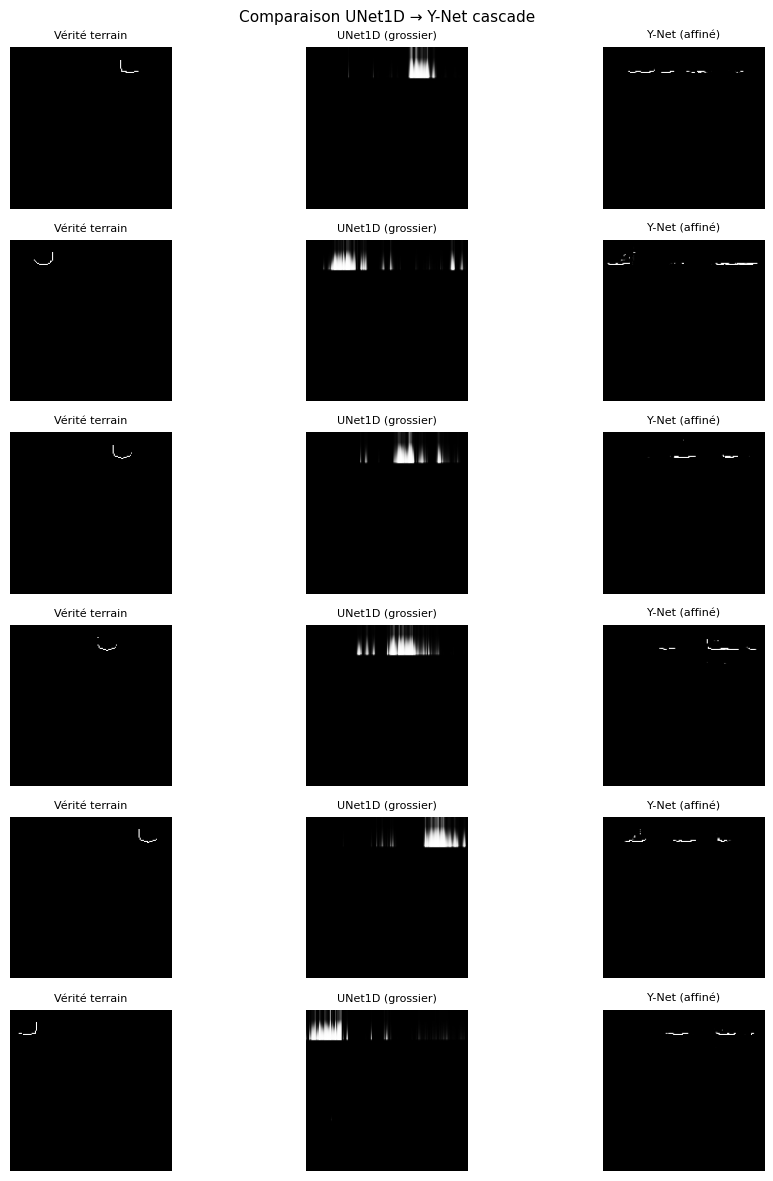

In [39]:
def collect_preds_ynet(model, loader, device):
    """Collecte prédictions pour le Y-Net (triplets en entrée)."""
    model.eval()
    all_probs, all_targets = [], []
    with torch.no_grad():
        for x_sig, x_coarse, y in loader:
            x_sig, x_coarse = x_sig.to(device), x_coarse.to(device)
            probs = torch.sigmoid(model(x_sig.squeeze(1), x_coarse)).cpu().numpy()
            all_probs.append(probs.flatten())
            all_targets.append(y.numpy().flatten())
    return np.concatenate(all_probs), np.concatenate(all_targets)


def show_cascade_comparison(model_base, model_ynet, loader_base,
                             loader_casc, device, num_samples=6,
                             threshold=0.5):
    """Affiche GT / UNet1D grossier / Y-Net affiné côte à côte."""
    model_base.eval()
    model_ynet.eval()
    shown = 0
    fig, axes = plt.subplots(num_samples, 3, figsize=(10, num_samples * 2))

    base_iter = iter(loader_base)
    casc_iter = iter(loader_casc)

    while shown < num_samples:
        x_base, y_base = next(base_iter)
        x_sig, x_coarse, y_casc = next(casc_iter)

        with torch.no_grad():
            prob_base = torch.sigmoid(
                model_base(x_base.to(device))).cpu().numpy()
            prob_ynet = torch.sigmoid(
                model_ynet(x_sig.squeeze(1).to(device), x_coarse.to(device))).cpu().numpy()

        for i in range(x_base.size(0)):
            if shown >= num_samples:
                break
            axes[shown, 0].imshow(y_base[i].squeeze(), cmap='gray', vmin=0, vmax=1)
            axes[shown, 0].set_title('Vérité terrain', fontsize=8)
            axes[shown, 0].axis('off')

            axes[shown, 1].imshow(prob_base[i].squeeze(), cmap='gray', vmin=0, vmax=1)
            axes[shown, 1].set_title('UNet1D (grossier)', fontsize=8)
            axes[shown, 1].axis('off')

            axes[shown, 2].imshow(prob_ynet[i].squeeze(), cmap='gray', vmin=0, vmax=1)
            axes[shown, 2].set_title('Y-Net (affiné)', fontsize=8)
            axes[shown, 2].axis('off')
            shown += 1

    plt.suptitle('Comparaison UNet1D → Y-Net cascade', fontsize=11)
    plt.tight_layout()
    plt.show()


# Métriques Y-Net
probs_yn, targets_yn = collect_preds_ynet(model_ynet, casc_test_loader, device)
thresholds = np.linspace(0.05, 0.95, 60)
f1s_yn = [compute_metrics(probs_yn, targets_yn, t)['F1'] for t in thresholds]
best_t_yn = thresholds[np.argmax(f1s_yn)]
metrics_yn = compute_metrics(probs_yn, targets_yn, best_t_yn)

print(f'\nY-Net cascade — seuil optimal : {best_t_yn:.2f}')
for k, v in metrics_yn.items():
    print(f'  {k:<12}: {v:.4f}')

# Comparaison visuelle
show_cascade_comparison(
    model_unet, model_ynet,
    test_loader, casc_test_loader,
    device, num_samples=6, threshold=best_t_yn
)


In [40]:
# Tableau comparatif : SimpleCNN / UNet1D / Y-Net cascade
print(f'{'Métrique':<14} {'U-Net':>12} {'Y-Net':>12}')
print('-' * 52)
for metric in ['Accuracy', 'Précision', 'Rappel', 'F1', 'IoU']:
    v_unet = metrics[metric]
    v_yn   = metrics_yn[metric]
    best = max(v_unet, v_yn)
    mark_unet = '  ←' if v_unet == best else ''
    mark_yn   = '  ←' if v_yn   == best else ''
    print(f'{metric:<14} '
          f'{v_unet:>12.4f}{mark_unet:<4} {v_yn:>12.4f}{mark_yn}')
print('-' * 52)
#print(f'{'Seuil opt.':<14} {results["best_t"]:>12.2f} '
      #f'{results["U-Net"]["best_t"]:>12.2f} {best_t_yn:>12.2f}')


Métrique              U-Net        Y-Net
----------------------------------------------------
Accuracy             0.9914           0.9977  ←
Précision            0.0674           0.2081  ←
Rappel               0.5380  ←        0.3738
F1                   0.1198           0.2673  ←
IoU                  0.0637           0.1543  ←
----------------------------------------------------



─── Diagnostic Y-Net cascade ───


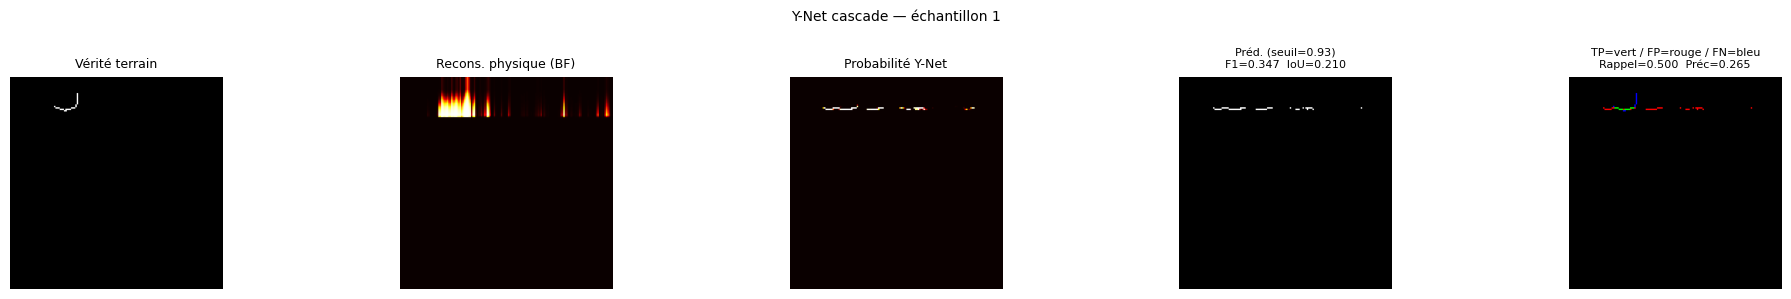

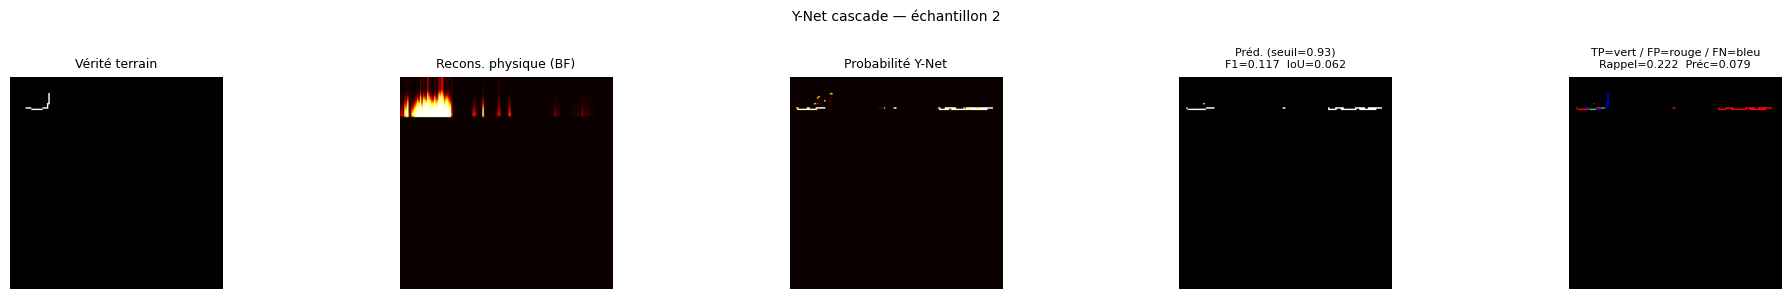

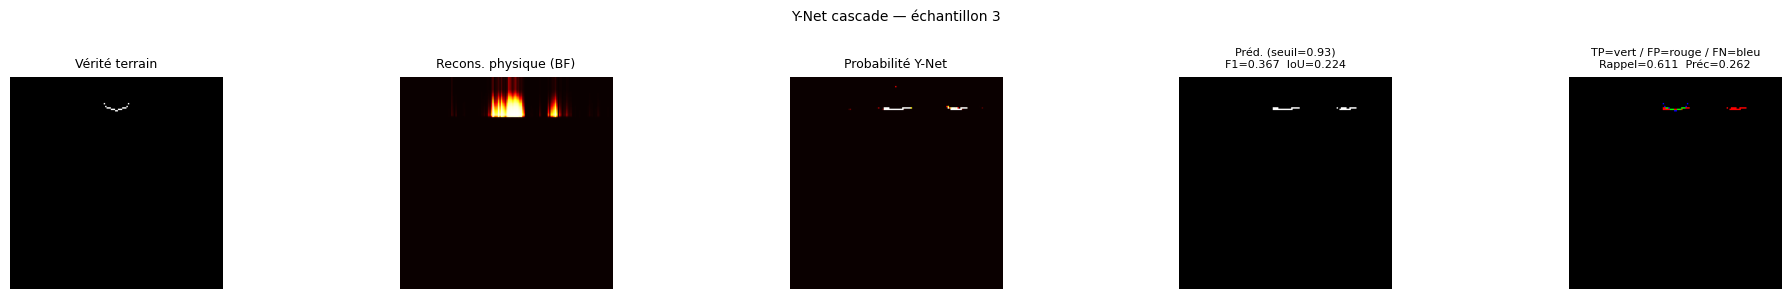

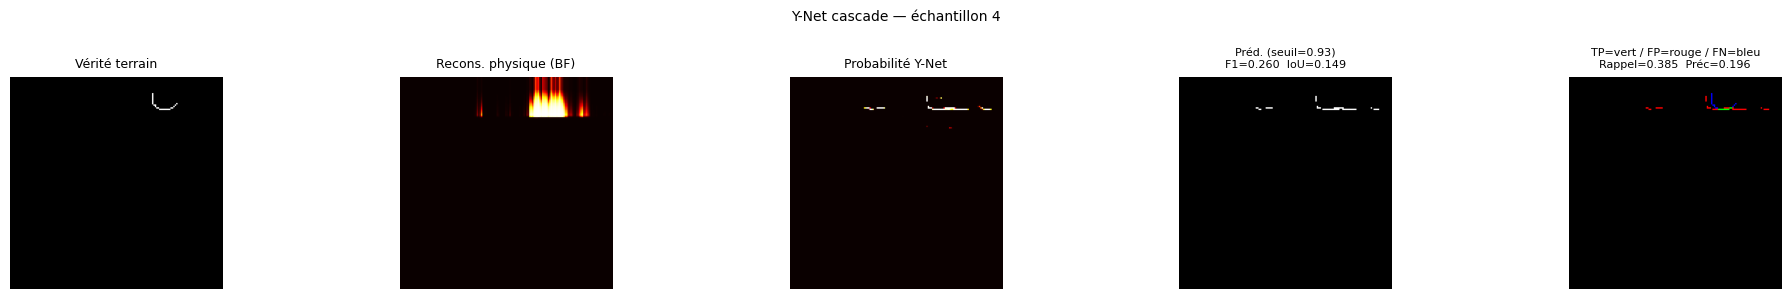

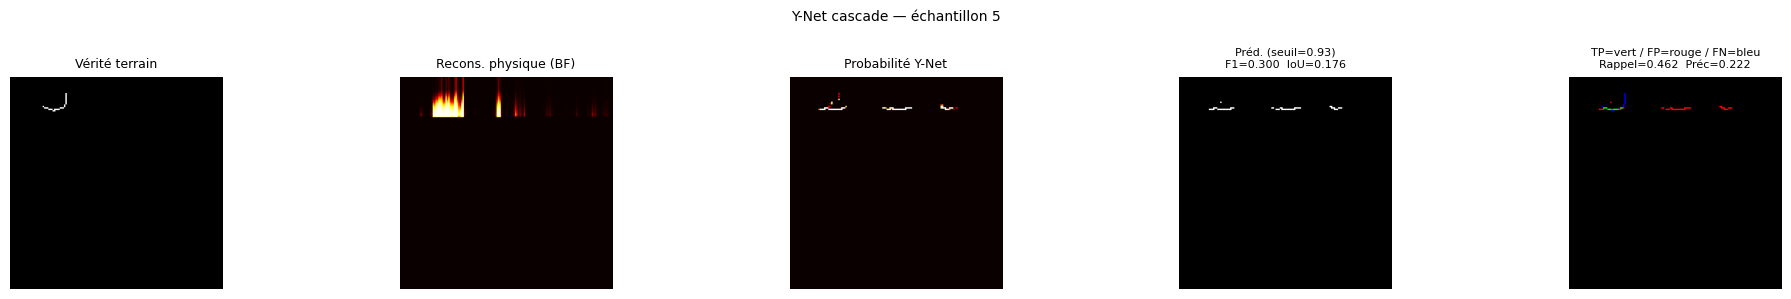

In [41]:
def show_diagnostic_ynet(model, loader, device, num_samples=5,
                          threshold=0.5, title='Y-Net'):
    """
    Diagnostic complet pour le Y-Net cascade.
    Affiche pour chaque exemple 5 colonnes :
      1. Vérité terrain
      2. Reconstruction physique (BF) — entrée Encodeur II
      3. Carte de probabilité prédite
      4. Prédiction binarisée
      5. Carte d'erreurs (TP=vert / FP=rouge / FN=bleu)
    """
    model.eval()
    shown = 0

    with torch.no_grad():
        for x_sig, x_coarse, y in loader:
            x_sig_d   = x_sig.to(device)
            x_coarse_d = x_coarse.to(device)
            probs = torch.sigmoid(model(x_sig_d.squeeze(1), x_coarse_d)).cpu().numpy()

            for i in range(x_sig.size(0)):
                if shown >= num_samples:
                    return

                prob   = probs[i].squeeze()                   # (150, 150)
                pred   = (prob >= threshold).astype(float)
                target = y[i].squeeze().numpy()               # (150, 150)
                bf     = x_coarse[i].squeeze().numpy()        # (150, 150)

                # Carte d'erreurs RGB
                err = np.zeros((*target.shape, 3))
                err[(pred==1) & (target==1)] = [0, 1, 0]     # TP vert
                err[(pred==1) & (target==0)] = [1, 0, 0]     # FP rouge
                err[(pred==0) & (target==1)] = [0, 0, 1]     # FN bleu

                # Métriques par image
                m = compute_metrics(prob.flatten(), target.flatten(), threshold)

                fig, axes = plt.subplots(1, 5, figsize=(20, 3))

                axes[0].imshow(target, cmap='gray', vmin=0, vmax=1)
                axes[0].set_title('Vérité terrain', fontsize=9)

                axes[1].imshow(bf, cmap='hot', vmin=0, vmax=1)
                axes[1].set_title('Recons. physique (BF)', fontsize=9)

                axes[2].imshow(prob, cmap='hot', vmin=0, vmax=1)
                axes[2].set_title('Probabilité Y-Net', fontsize=9)

                axes[3].imshow(pred, cmap='gray', vmin=0, vmax=1)
                axes[3].set_title(
                    f'Préd. (seuil={threshold:.2f})\n'
                    f'F1={m["F1"]:.3f}  IoU={m["IoU"]:.3f}',
                    fontsize=8
                )

                axes[4].imshow(err)
                axes[4].set_title(
                    f'TP=vert / FP=rouge / FN=bleu\n'
                    f'Rappel={m["Rappel"]:.3f}  Préc={m["Précision"]:.3f}',
                    fontsize=8
                )

                for ax in axes:
                    ax.axis('off')

                fig.suptitle(f'{title} — échantillon {shown+1}', fontsize=10)
                plt.tight_layout()
                plt.show()
                shown += 1

# ── Diagnostic Y-Net ─────────────────────────────────────────────────────────
print('\n─── Diagnostic Y-Net cascade ───')
show_diagnostic_ynet(
    model_ynet, casc_test_loader, device,
    num_samples=5, threshold=best_t_yn, title='Y-Net cascade'
)

In [42]:
# ════════════════════════════════════════════════════════════════════
# EXPLICABILITÉ : Saliency Maps + Grad-CAM 1D sur UNet2Ch
# ════════════════════════════════════════════════════════════════════

def compute_saliency(model, x, device):
    """
    Calcule la saliency map par rapport à l'entrée.
    x : (B, 9, 801) tensor
    Retourne : (B, 9, 801) importance absolue par position temporelle
    """
    model.eval()
    x_in = x.clone().to(device).requires_grad_(True)
    output = model(x_in)                     # (B, 1, 150, 150)
    # Score = somme des probabilités sur les pixels positifs prédits
    score = torch.sigmoid(output).sum()
    model.zero_grad()
    score.backward()
    saliency = x_in.grad.abs().cpu()         # (B, 9, 801)
    return saliency

def plot_importance_temporal(importance_mean, importance_std, method='Saliency',
                              signal_start=SIGNAL_START, fs=33333):
    """
    Affiche l'importance temporelle moyennée sur tous les échantillons.
    importance_mean : (9, 801)
    importance_std  : (9, 801)
    fs : fréquence d'échantillonnage en Hz (pour l'axe temporel)
    """
    n_cap = importance_mean.shape[0]
    L     = importance_mean.shape[1]
    t_ms  = (np.arange(L) + signal_start) / fs * 1000  # temps en ms

    fig, axes = plt.subplots(n_cap, 1, figsize=(14, n_cap * 1.4), sharex=True)
    if n_cap == 1:
        axes = [axes]

    # Importance globale (moyenne capteurs) pour détecter la fenêtre clé
    global_imp = importance_mean.mean(axis=0)  # (801,)

    # Fenêtre de pic (top 10% des valeurs)
    threshold_peak = np.percentile(global_imp, 90)
    peak_mask = global_imp >= threshold_peak
    if peak_mask.any():
        peak_start_ms = t_ms[np.where(peak_mask)[0].min()]
        peak_end_ms   = t_ms[np.where(peak_mask)[0].max()]

    for c in range(n_cap):
        mu  = importance_mean[c]
        std = importance_std[c]
        axes[c].fill_between(t_ms, mu - std, mu + std, alpha=0.25, color='steelblue')
        axes[c].plot(t_ms, mu, color='steelblue', linewidth=1.2)
        if peak_mask.any():
            axes[c].axvspan(peak_start_ms, peak_end_ms, alpha=0.15,
                            color='red', label='Zone clé (top 10%)')
        axes[c].set_ylabel(f'Cap. {c+1}', fontsize=8)
        axes[c].set_yticks([])

    axes[-1].set_xlabel('Temps (ms)', fontsize=9)
    if peak_mask.any():
        axes[0].legend(fontsize=8)
    fig.suptitle(
        f'{method} — Importance temporelle moyenne\n'
        f'(zone rouge = fenêtre la plus utilisée par le réseau)',
        fontsize=10
    )
    plt.tight_layout()
    plt.show()

    if peak_mask.any():
        print(f'Fenêtre clé détectée : {peak_start_ms:.2f} ms → {peak_end_ms:.2f} ms')
        print(f'  Indices signal     : {np.where(peak_mask)[0].min()} → {np.where(peak_mask)[0].max()}')


def plot_importance_heatmap(importance_mean, method='Saliency', signal_start=SIGNAL_START, fs=33333):
    """
    Affiche une heatmap (capteurs x temps) de l'importance.
    Permet de voir si les zones importantes sont décalées entre capteurs
    (ce qui indiquerait que le réseau utilise bien les délais inter-capteurs).
    """
    L    = importance_mean.shape[1]
    t_ms = (np.arange(L) + signal_start) / fs * 1000

    fig, ax = plt.subplots(figsize=(14, 3))
    im = ax.imshow(
        importance_mean, aspect='auto', cmap='hot',
        extent=[t_ms[0], t_ms[-1], importance_mean.shape[0]+0.5, 0.5]
    )
    plt.colorbar(im, ax=ax, label='Importance')
    ax.set_xlabel('Temps (ms)')
    ax.set_ylabel('Capteur')
    ax.set_yticks(range(1, importance_mean.shape[0]+1))
    ax.set_title(
        f'{method} — Heatmap importance (capteurs x temps)\n'
        f'Des décalages horizontaux entre capteurs indiquent que le réseau\n'
        f'exploite les délais inter-capteurs pour estimer l\'angle.',
        fontsize=9
    )
    plt.tight_layout()
    plt.show()


print('Fonctions XAI definies.')


Fonctions XAI definies.


Calcul des Saliency Maps...
Saliency calculee sur 50 echantillons.


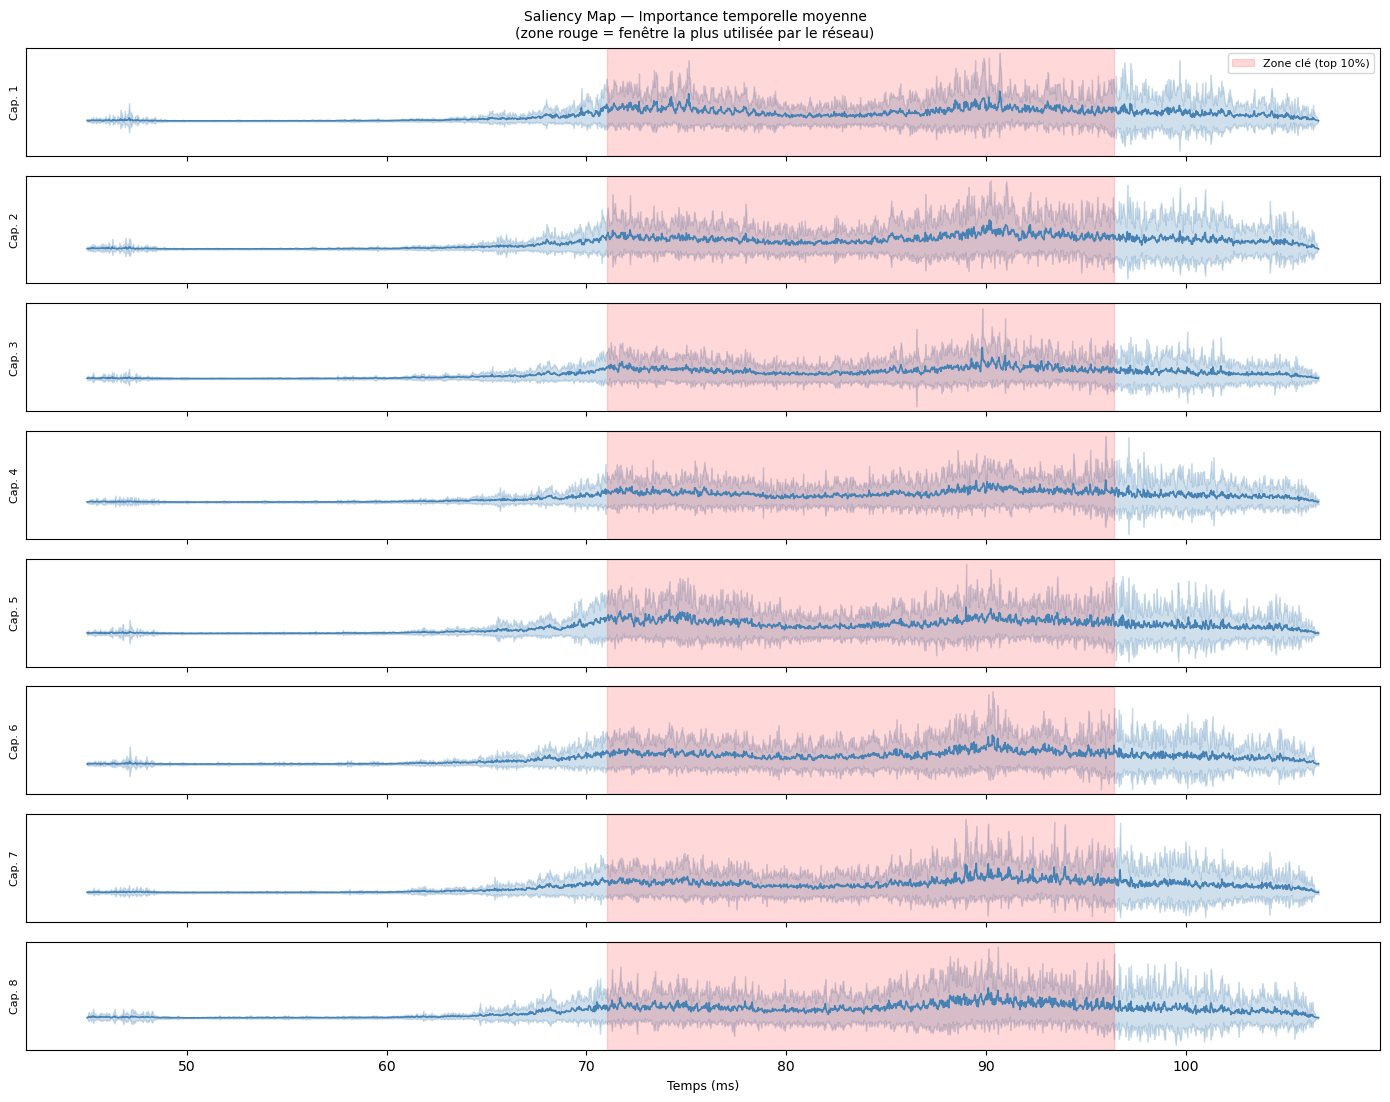

Fenêtre clé détectée : 71.01 ms → 96.42 ms
  Indices signal     : 867 → 1714


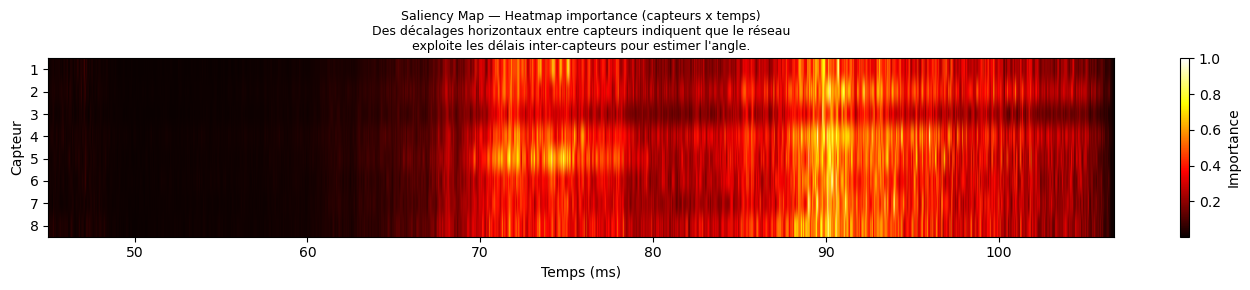

In [43]:
# ── Calcul des saliency maps et Grad-CAM sur le dataset de test ──────────────
# Pour une analyse par classe, remplacer test_loader par
# test_loaders_by_class['Rond'] etc.

N_SAMPLES_XAI = 50   # nombre d'échantillons à analyser (augmenter pour plus de robustesse)

# ── 1) Saliency Maps ─────────────────────────────────────────────────────────
print('Calcul des Saliency Maps...')
sal_all = []
model_unet.eval()

for x, y in test_loader:
    sal = compute_saliency(model_unet, x, device)  # (B, 9, 801)
    sal_all.append(sal.numpy())
    if sum(s.shape[0] for s in sal_all) >= N_SAMPLES_XAI:
        break

sal_all   = np.concatenate(sal_all, axis=0)[:N_SAMPLES_XAI]  # (N, 9, 801)
sal_mean  = sal_all.squeeze(1).mean(axis=0)   # (9, 801)
sal_std   = sal_all.squeeze(1).std(axis=0)    # (9, 801)

# Normaliser par capteur pour faciliter la comparaison
for c in range(sal_mean.shape[0]):
    vmax = sal_mean[c].max()
    if vmax > 0:
        sal_mean[c] /= vmax
        sal_std[c]  /= vmax

print(f'Saliency calculee sur {N_SAMPLES_XAI} echantillons.')
plot_importance_temporal(sal_mean, sal_std, method='Saliency Map')
plot_importance_heatmap(sal_mean, method='Saliency Map')

(300, 8, 2056)
(300, 8)
(300, 8)
(8,)


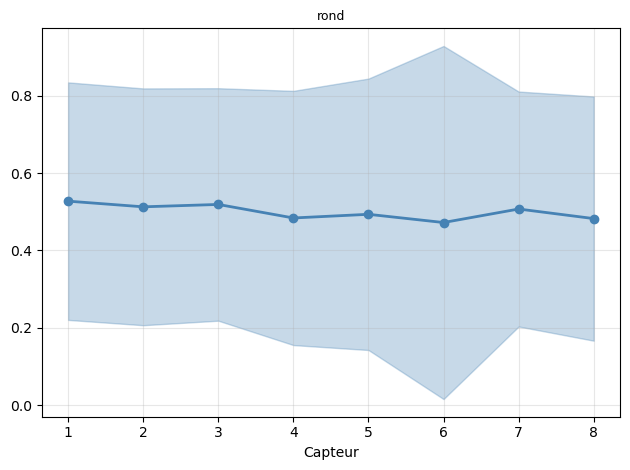

Variance inter-capteurs par classe (plus c'est élevé, plus le profil est asymétrique) :


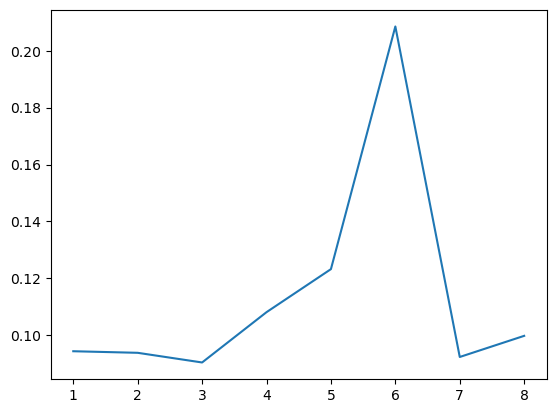

In [44]:
# ════════════════════════════════════════════════════════════════════
# ANALYSE 1 : Profil d'amplitude inter-capteurs
# Est-ce que le réseau utilise l'énergie par capteur pour estimer l'angle ?
# ════════════════════════════════════════════════════════════════════

def compute_energy_profile(X,signal_start=0):
    """
    Calcule l'énergie RMS de chaque capteur pour chaque échantillon.
    X : (N, 9, 801)
    Retourne : (N, 9) — énergie par capteur
    """
    return np.sqrt((X ** 2).mean(axis=2))   # (N, 8)
# Calculer le profil d'énergie sur le test set
X_test = X   # (N_test, 9, 801)
print(X_test.shape)
energy = compute_energy_profile(X_test)   # (N_test, 8)
# Normaliser chaque profil entre 0 et 1 pour comparer les formes
energy_norm = energy - energy.min(axis=1, keepdims=True)
denom = energy_norm.max(axis=1, keepdims=True)
denom[denom == 0] = 1
energy_norm = energy_norm / denom   # (N_test, 8)
print(energy_norm.shape)

e_class = energy_norm       # (N_class, 9)

print(energy_norm.shape)
mu  = energy_norm.mean(axis=0)        # (9,)
std = energy_norm.std(axis=0)         # (9,)
print(mu.shape)

plt.fill_between(range(1, 9), mu - std, mu + std, alpha=0.3, color='steelblue')
plt.plot(range(1, 9), mu, 'o-', color='steelblue', linewidth=2, markersize=6)
plt.title('rond', fontsize=9)
plt.xlabel('Capteur')
plt.xticks(range(1, 9))
plt.grid(True, alpha=0.3)

fig.suptitle(
    'Profil d\'énergie moyen par capteur et par classe\n'
    'Un pic asymétrique indique que l\'amplitude encode l\'angle',
    fontsize=9
)
plt.tight_layout()
plt.show()

# Stats : variance inter-capteurs (mesure de l'asymétrie du profil)
print('Variance inter-capteurs par classe (plus c\'est élevé, plus le profil est asymétrique) :')
var  = energy_norm.var(axis=0)
plt.plot(range(1,9), var)

Calcul des corrélations croisées (peut prendre ~30s)...
Délais inter-capteurs calculés sur 50 échantillons.
Délai moyen relatif au capteur 1 (ms) :
  Capteur 2 : +1.1026 ms ± 0.5007
  Capteur 3 : -0.8966 ms ± 0.8253
  Capteur 4 : +12.0848 ms ± 2.6260
  Capteur 5 : -0.7847 ms ± 1.6377
  Capteur 6 : +12.3462 ms ± 2.8334
  Capteur 7 : -0.3510 ms ± 1.8522
  Capteur 8 : +0.6818 ms ± 1.8870


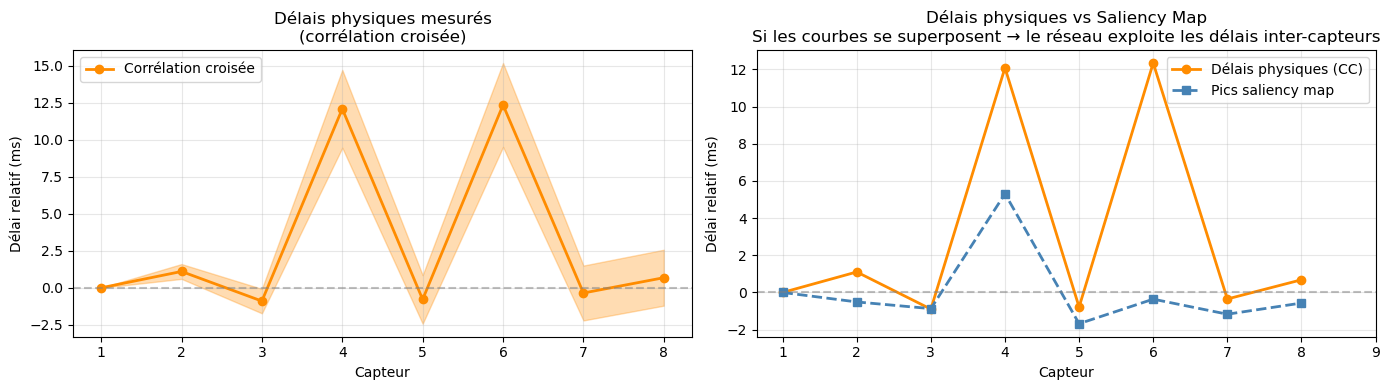

In [45]:
# ════════════════════════════════════════════════════════════════════
# ANALYSE 2 : Corrélation croisée inter-capteurs
# Mesure le délai physique réel entre capteurs
# et le compare à ce que la saliency map détecte
# ════════════════════════════════════════════════════════════════════

def compute_cross_correlation_delays(X, ref_capteur=0, fs=33333):
    """
    Calcule le délai entre le capteur de référence et chaque autre capteur
    via corrélation croisée.
    X  : (N, 9, 801)
    Retourne : (N, 8) délais en ms (capteurs 1-8 relatifs au capteur 0)
    """
    N, n_cap, L = X.shape
    delays = np.zeros((N, n_cap - 1))

    for i in range(N):
        ref = X[i, ref_capteur]       # signal de référence (801,)
        for j in range(1, n_cap):
            sig = X[i, j]
            # Corrélation croisée normalisée
            corr = np.correlate(sig, ref, mode='full')   # (1601,)
            lag  = np.argmax(np.abs(corr)) - (L - 1)    # décalage en samples
            delays[i, j-1] = lag / fs * 1000             # conversion en ms
    return delays

print('Calcul des corrélations croisées (peut prendre ~30s)...')
X_test_raw = X_raw   # signaux non normalisés pour la corrélation

# Calculer sur un sous-ensemble pour la rapidité
N_CC = 50
delays = compute_cross_correlation_delays(X_test_raw[:,:N_CC])  # (N_CC, 8)

delay_mean = delays.mean(axis=0)   # (8,) délai moyen par capteur
delay_std  = delays.std(axis=0)

print(f'Délais inter-capteurs calculés sur {N_CC} échantillons.')
print('Délai moyen relatif au capteur 1 (ms) :')
for j in range(7):
    print(f'  Capteur {j+2} : {delay_mean[j]:+.4f} ms ± {delay_std[j]:.4f}')

# ── Comparer délais physiques vs pics de saliency map ────────────────────────
# Récupérer les pics de la saliency map (calculée à la cellule précédente)
L    = sal_mean.shape[1]
t_ms = (np.arange(L) + 1200) / 33333 * 1000

sal_peak_times = []
for c in range(sal_mean.shape[0]):
    sal_peak_times.append(t_ms[sal_mean[c].argmax()])

# Délais saliency relatifs au capteur 1
sal_delays_rel = np.array(sal_peak_times) - sal_peak_times[0]   # (9,)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Gauche : délais physiques (corrélation croisée) ──────────────────────────
delay_all = np.concatenate([[0], delay_mean])   # ajouter capteur 1 = 0
axes[0].fill_between(
    range(1, 9),
    delay_all - np.concatenate([[0], delay_std]),
    delay_all + np.concatenate([[0], delay_std]),
    alpha=0.3, color='darkorange'
)
axes[0].plot(range(1, 9), delay_all, 'o-', color='darkorange',
             linewidth=2, markersize=6, label='Corrélation croisée')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Capteur')
axes[0].set_ylabel('Délai relatif (ms)')
axes[0].set_title('Délais physiques mesurés\n(corrélation croisée)')
axes[0].set_xticks(range(1, 9))
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# ── Droite : comparaison délais physiques vs saliency map ────────────────────
axes[1].plot(range(1, 9), delay_all, 'o-', color='darkorange',
             linewidth=2, markersize=6, label='Délais physiques (CC)')
axes[1].plot(range(1, 9), sal_delays_rel, 's--', color='steelblue',
             linewidth=2, markersize=6, label='Pics saliency map')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Capteur')
axes[1].set_ylabel('Délai relatif (ms)')
axes[1].set_title(
    'Délais physiques vs Saliency Map\n'
    'Si les courbes se superposent → le réseau exploite les délais inter-capteurs'
)
axes[1].set_xticks(range(1, 10))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [46]:
# ════════════════════════════════════════════════════════════════════
# INTERPRÉTATION : le réseau utilise-t-il les délais ou l'amplitude ?
# ════════════════════════════════════════════════════════════════════

from scipy.stats import pearsonr

# Corrélation entre délais physiques et pics saliency
corr_delays, p_delays = pearsonr(delay_all[1:], sal_delays_rel[1:])

# Variance du profil d'énergie (mesure de l'asymétrie)
var_energie = energy_norm.var(axis=1).mean()

print('=' * 55)
print('  DIAGNOSTIC : source d\'information angulaire')
print('=' * 55)
print(f'\n  Corrélation délais physiques / saliency map :')
print(f'    r = {corr_delays:.3f}  (p = {p_delays:.4f})')
if abs(corr_delays) > 0.7 and p_delays < 0.05:
    print('    → ✅ Le réseau exploite les délais inter-capteurs')
else:
    print('    → ❌ Le réseau n\'exploite PAS les délais inter-capteurs')

print(f'\n  Variance inter-capteurs du profil d\'énergie :')
print(f'    var = {var_energie:.4f}')
if var_energie > 0.05:
    print('    → ✅ Le profil d\'amplitude est asymétrique (info angulaire présente)')
else:
    print('    → ❌ Le profil d\'amplitude est plat (peu d\'info angulaire)')

print('\n  Conclusion :')
if abs(corr_delays) > 0.7:
    print('    Le réseau utilise principalement les DÉLAIS inter-capteurs.')
    print('    → Équivalent au beamforming classique.')
    print('    → Cohérent avec la biologie du dauphin (stéréophonie).')
elif var_energie > 0.05:
    print('    Le réseau utilise principalement l\'AMPLITUDE par capteur.')
    print('    → Plus robuste au bruit mais moins précis en angle.')
else:
    print('    Source d\'information angulaire non identifiée clairement.')
    print('    → Essayer avec un dataset mono-classe à angles variés.')
print('=' * 55)

  DIAGNOSTIC : source d'information angulaire

  Corrélation délais physiques / saliency map :
    r = 0.707  (p = 0.0756)
    → ❌ Le réseau n'exploite PAS les délais inter-capteurs

  Variance inter-capteurs du profil d'énergie :
    var = 0.1008
    → ✅ Le profil d'amplitude est asymétrique (info angulaire présente)

  Conclusion :
    Le réseau utilise principalement les DÉLAIS inter-capteurs.
    → Équivalent au beamforming classique.
    → Cohérent avec la biologie du dauphin (stéréophonie).


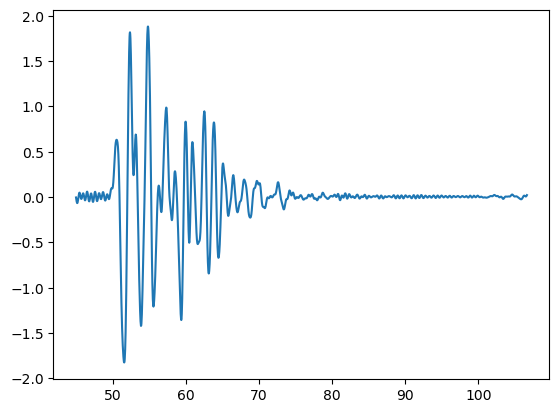

In [47]:
plt.plot((np.arange(L) + SIGNAL_START) / 33333 * 1000, X[0][0])

(8, 2056)


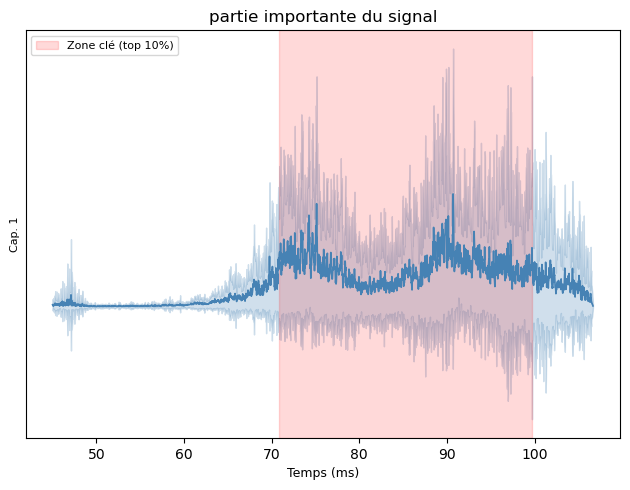

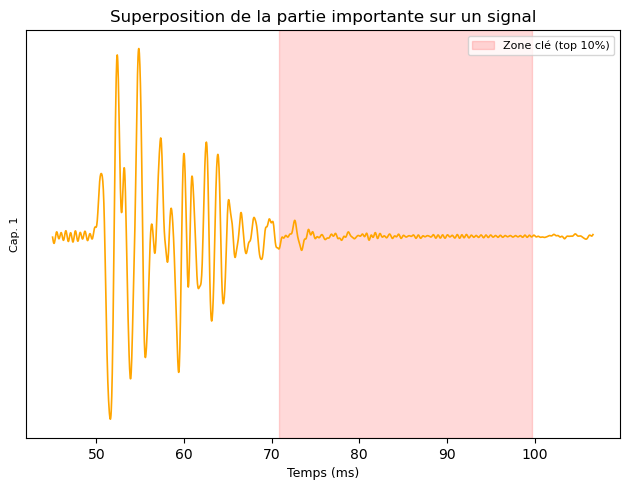

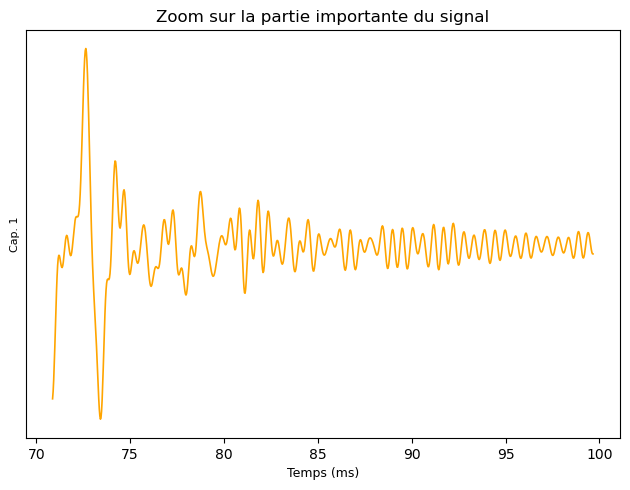

Fenêtre clé détectée : 70.86 ms → 99.69 ms
  Indices signal     : 862 → 1823


In [48]:
def plot_importance_temporal_for_a_capteur(importance_mean, importance_std, method='Saliency',
                              signal_start=SIGNAL_START, fs=33333):
    """
    Affiche l'importance temporelle moyennée sur tous les échantillons.
    importance_mean : (801,)
    importance_std  : (801,)
    fs : fréquence d'échantillonnage en Hz (pour l'axe temporel)
    """
    n_cap = 1
    L     = importance_mean.shape[0]
    t_ms  = (np.arange(L) + signal_start) / fs * 1000  # temps en ms

    # Fenêtre de pic (top 10% des valeurs)
    threshold_peak = np.percentile(importance_mean, 90)
    peak_mask = importance_mean >= threshold_peak
    if peak_mask.any():
        peak_start_idx = np.where(peak_mask)[0].min()
        peak_start_ms = t_ms[peak_start_idx]
        peak_end_idx = np.where(peak_mask)[0].max()
        peak_end_ms   = t_ms[peak_end_idx]
    plt.fill_between(t_ms, importance_mean - importance_std, importance_mean + importance_std, alpha=0.25, color='steelblue')
    plt.plot(t_ms, importance_mean, color='steelblue', linewidth=1.2)
    if peak_mask.any():
        plt.axvspan(peak_start_ms, peak_end_ms, alpha=0.15,
                            color='red', label='Zone clé (top 10%)')
    plt.ylabel(f'Cap. {1}', fontsize=8)
    plt.yticks([])

    plt.xlabel('Temps (ms)', fontsize=9)
    if peak_mask.any():
        plt.legend(fontsize=8)
    fig.suptitle(
        f'{method} — Importance temporelle moyenne\n'
        f'(zone rouge = fenêtre la plus utilisée par le réseau)',
        fontsize=8
    )
    plt.tight_layout()
    plt.title('partie importante du signal')
    plt.show()
    
    # Graphique partie importante du signal
    plt.plot(t_ms, X[0][0], color='orange', linewidth=1.2)
    if peak_mask.any():
        plt.axvspan(peak_start_ms, peak_end_ms, alpha=0.15,
                            color='red', label='Zone clé (top 10%)')
    plt.ylabel(f'Cap. {1}', fontsize=8)
    plt.yticks([])

    plt.xlabel('Temps (ms)', fontsize=9)
    if peak_mask.any():
        plt.legend(fontsize=8)
    fig.suptitle(
        f'{method} — Importance temporelle moyenne\n'
        f'(zone rouge = fenêtre la plus utilisée par le réseau)',
        fontsize=8
    )
    plt.tight_layout()
    plt.title('Superposition de la partie importante sur un signal')
    plt.show()
    
    # Zoom sur la partie importante 
    plt.plot(t_ms[peak_start_idx:peak_end_idx], X[0][0][peak_start_idx:peak_end_idx], color='orange', linewidth=1.2)
    plt.ylabel(f'Cap. {1}', fontsize=8)
    plt.yticks([])

    plt.xlabel('Temps (ms)', fontsize=9)
    plt.tight_layout()
    plt.title('Zoom sur la partie importante du signal')
    plt.show()

    if peak_mask.any():
        print(f'Fenêtre clé détectée : {peak_start_ms:.2f} ms → {peak_end_ms:.2f} ms')
        print(f'  Indices signal     : {np.where(peak_mask)[0].min()} → {np.where(peak_mask)[0].max()}')
print(sal_mean.shape)
plot_importance_temporal_for_a_capteur(sal_mean[0], sal_std[0], method='Saliency Map')